<a href="https://colab.research.google.com/github/Rushikesh042/VLM-Dental-Classification/blob/main/MMDental_Dataset_Pre_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MMDental DATASET PRE-PROCESSING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/Teeth_Segmentation_Classification')
# ----------------------------------------------
MMDENTAL_RAW   = PROJECT_ROOT / 'MMDental'

WORK_DIR     = Path('/content/work')
PREPROC_ROOT = PROJECT_ROOT / 'Preprocessed_Dataset'
MMD_PREPROC  = PREPROC_ROOT / 'MMDental'
LOG_DIR = PROJECT_ROOT / 'Logs'

for d in [
    WORK_DIR,
    MMD_PREPROC,
    LOG_DIR,
    MMD_PREPROC / 'images_3d',
    MMD_PREPROC / 'images_teacher_space',
    MMD_PREPROC / 'manifests',
    MMD_PREPROC / 'qa',
    MMD_PREPROC / 'logs',
]:
    d.mkdir(exist_ok=True, parents=True)

print(f"Project root:  {PROJECT_ROOT}")
print(f"  MMD Raw:     {MMDENTAL_RAW}  {'OK' if MMDENTAL_RAW.exists() else 'MISSING'}")
print(f"  Preproc:     {PREPROC_ROOT}")
print(f"  Logs:        {LOG_DIR}")

Project root:  /content/drive/MyDrive/Teeth_Segmentation_Classification
  MMD Raw:     /content/drive/MyDrive/Teeth_Segmentation_Classification/MMDental  OK
  Preproc:     /content/drive/MyDrive/Teeth_Segmentation_Classification/Preprocessed_Dataset
  Logs:        /content/drive/MyDrive/Teeth_Segmentation_Classification/Logs


In [ ]:
!pip install -q SimpleITK nibabel monai einops tqdm
print("Dependencies installed.")

Dependencies installed.


In [ ]:
import subprocess
import os, sys, json, gc, hashlib, logging, re
from dataclasses import dataclass, field, asdict
from typing import Optional, Tuple, Dict, List, Any
from scipy.ndimage import binary_dilation

import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
)
log = logging.getLogger('preproc')

print(f"NumPy:     {np.__version__}")
print(f"pandas:    {pd.__version__}")
print(f"SimpleITK: {sitk.Version_VersionString()}")

NumPy:     2.0.2
pandas:    2.2.2
SimpleITK: 2.5.5


## 1. MMDental LABEL EXTRACTION


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Teeth_Segmentation_Classification/MMDental/medical_records.csv')
df.head()

,Filename,Sex,Age,Main appeal,Subsequent,Present medical history,Past medical history,Oral Check,Diagnosis,Treatment plan,Handle,Doctor advices
0,1,female,20.0,"Protruding teeth, consultation for correction",NaN,The patient complained that he had undergone o...,NaN,Convex type. Brackets are visible in the upper...,Malformed teeth (K07.302),"The maxillary gap is closed, and the anterior ...","Explain the condition, inform the patient, ask...",Make a follow-up appointment one week later fo...
1,2,male,22.0,NaN,"Follow-up visit, no discomfort",NaN,Nothing special,"*14 Temporarily sealed, no pain when percussion.",NaN,NaN,"*14 Remove the temporary seal, rinse and blot ...",NaN
2,2,male,22.0,Right tooth pain for several days,NaN,The patient complained of tooth pain on the ri...,Nothing special,*14 There is a deep carious cavity and dental ...,*18 impacted teeth *14 chronic pulpitis,*18 extractions *14 root canal treatments,*18 Local disinfection with povidone-iodine an...,Strictly abide by the &quot;Precautions after ...
3,3,female,25.0,Request tooth extraction,NaN,"Denial of systemic disease history, family his...",NaN,"Buccal eruption can be seen in *13, located be...",NaN,*13 Remove,"Local povidone iodine disinfection, 4% atecain...",Follow-up for discomfort.
4,3,female,25.0,Rescheduled for extraction tomorrow,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Filename,Sex,Age,Main appeal,Subsequent,Present medical history,Past medical history,Oral Check,Diagnosis,Treatment plan,Handle,Doctor advices
2119,659,female,23.0,The upper right front tooth has not erupted an...,NaN,The patient complained that since the tooth re...,Nothing special.,"13 is not cute yet, 12 can be palpated on the ...",Misaligned teeth (K07.302)13 Impacted teeth (K...,NaN,"Explain the condition, keep the patient and fa...",Instruct patients to avoid eating foods that a...
2120,660,male,20.0,NaN,There was no abnormality when using the tempor...,NaN,"He denies a history of systemic diseases, fami...","*36 The temporary crown is in place, with no p...",NaN,*36 wears teeth.,*36 Remove the temporary crown and try on the ...,Follow-up for discomfort. Avoid biting hard ob...
2121,660,male,20.0,NaN,Reexamination of lower left posterior teeth,NaN,"He denies a history of systemic disease, infec...","36 Temporarily seal things for storage, explor...",36 Tooth defects (K07.303).,36 full crown restoration.,"36 Remove the temporary seal, high-strength re...",Do not bite hard objects and return to the cli...
2122,660,male,20.0,NaN,NaN,NaN,"He denied any history of systemic diseases, fa...","*36 is temporarily sealed, knock (-).",36Pulpitis(K04.000),*36 affected teeth were prepared and filled ac...,"*36 Remove the temporary seal, explore 4 roots...","Chew after 2 hours, and do not bite hard objec..."
2123,660,male,20.0,The left lower back tooth has been painful for...,NaN,The left lower back tooth had been suffering f...,"He denies the history of systemic diseases, in...","36 Extensive caries, detecting decay, sensitiv...",36Pulpitis(K04.000),36 After the root canal treatment of the tooth...,36 Under local infiltration anesthesia with 1....,NaN


## 2. MMDental PATHS, INSTALL, IMPORTS

In [ ]:
import dataclasses
import gc
import html
import json
import logging
import pathlib
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk
import sklearn.model_selection
import tqdm.auto


SEED = 42
np.random.seed(SEED)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    datefmt='%H:%M:%S',
)

log = logging.getLogger('mmd_preproc')

PROJECT_ROOT = pathlib.Path('/content/drive/MyDrive/Teeth_Segmentation_Classification')
MMDENTAL_RAW = PROJECT_ROOT / 'MMDental'

MMD_PREPROC = PROJECT_ROOT / 'Preprocessed_Dataset' / 'MMDental'
MMD_IMG3D_DIR = MMD_PREPROC / 'images_3d'
MMD_TEACHER_IMG_DIR = MMD_PREPROC / 'images_teacher_space'
MMD_MANIFEST_DIR = MMD_PREPROC / 'manifests'
MMD_QA_DIR = MMD_PREPROC / 'qa'
MMD_LOG_DIR = MMD_PREPROC / 'logs'

MMD_MANIFEST_CSV = MMD_MANIFEST_DIR / 'manifest.csv'
MMD_SPLITS_CSV = MMD_MANIFEST_DIR / 'splits.csv'
MMD_QA_JSONL = MMD_QA_DIR / 'qa_pairs.jsonl'

for directory in [
    MMD_PREPROC,
    MMD_IMG3D_DIR,
    MMD_TEACHER_IMG_DIR,
    MMD_MANIFEST_DIR,
    MMD_QA_DIR,
    MMD_LOG_DIR,
]:
    directory.mkdir(exist_ok=True, parents=True)

print(f"MMDental raw:          {MMDENTAL_RAW} {'OK' if MMDENTAL_RAW.exists() else 'MISSING'}")
print(f"MMDental preprocessed: {MMD_PREPROC}")
print(f"NumPy:                 {np.__version__}")
print(f"pandas:                {pd.__version__}")
print(f"SimpleITK:             {sitk.Version_VersionString()}")

MMDental raw:          /content/drive/MyDrive/Teeth_Segmentation_Classification/MMDental OK
MMDental preprocessed: /content/drive/MyDrive/Teeth_Segmentation_Classification/Preprocessed_Dataset/MMDental
NumPy:                 2.0.2
pandas:                2.2.2
SimpleITK:             2.5.5


## 3. MMDental CONFIG

In [ ]:
@dataclasses.dataclass
class MMDConfig:
    binary_class_names: tuple[str, str] = ('NON_PERIODONTITIS', 'PERIODONTITIS')

    use_all_covered_labels: bool = True
    default_non_periodontitis_weight: float = 0.35
    medium_confidence_weight: float = 0.70
    high_confidence_weight: float = 1.00

    classifier_target_shape: tuple[int, int, int] = (112, 176, 176)        # D, H, W
    classifier_target_spacing: tuple[float, float, float] = (1.0, 1.0, 1.0)  # mm, isotropic
    teacher_target_spacing: tuple[float, float, float] = (0.4, 0.4, 0.4)     # mm, matches TF2

    fixed_clip_range: tuple[float, float] = (-1000.0, 3000.0)
    use_percentile_clip: bool = True
    clip_percentiles: tuple[float, float] = (0.5, 99.5)
    save_dtype_image: str = 'float32'

    val_frac: float = 0.15
    test_frac: float = 0.15

    skip_existing: bool = True
    text_max_chars: int = 800


CFG = MMDConfig()

print("MMDental config:")
for key, value in dataclasses.asdict(CFG).items():
    print(f"  {key}: {value}")

MMDental config:
  binary_class_names: ('NON_PERIODONTITIS', 'PERIODONTITIS')
  use_all_covered_labels: True
  default_non_periodontitis_weight: 0.35
  medium_confidence_weight: 0.7
  high_confidence_weight: 1.0
  classifier_target_shape: (112, 176, 176)
  classifier_target_spacing: (1.0, 1.0, 1.0)
  teacher_target_spacing: (0.4, 0.4, 0.4)
  fixed_clip_range: (-1000.0, 3000.0)
  use_percentile_clip: True
  clip_percentiles: (0.5, 99.5)
  save_dtype_image: float32
  val_frac: 0.15
  test_frac: 0.15
  skip_existing: True
  text_max_chars: 800


## 4. 3D VOLUME UTILITIES

In [ ]:
def load_file_volume(path: Path) -> Dict[str, Any]:
    """Load .mha or .nii.gz via SimpleITK, canonicalize orientation to LPS.
    Returns array + metadata. LPS = standard radiological orientation, so left/right
    sides are consistent across all volumes — required for per-tooth FDI labels."""
    img = sitk.ReadImage(str(path))
    img = sitk.DICOMOrient(img, 'LPS')   # canonical orientation
    arr = sitk.GetArrayFromImage(img)    # [D, H, W]
    return {
        'array':     arr,
        'spacing':   tuple(img.GetSpacing()),
        'origin':    tuple(img.GetOrigin()),
        'direction': tuple(img.GetDirection()),
        'dtype':     str(arr.dtype),
        'shape':     tuple(arr.shape),
    }


def crop_or_pad_center(
    array: np.ndarray,
    target_shape: tuple[int, int, int],
    pad_value: float = 0.0,
) -> np.ndarray:
    """Center crop or pad a [D, H, W] array to target_shape. Pure index/pad op:
    it changes the grid only, never resampling or warping geometry."""
    array = np.asarray(array)

    pad = [
        (max(0, (t - s) // 2), max(0, t - s - (t - s) // 2))
        for s, t in zip(array.shape, target_shape)
    ]
    if any(before or after for before, after in pad):
        array = np.pad(array, pad, mode='constant', constant_values=pad_value)

    starts = [max(0, (c - t) // 2) for c, t in zip(array.shape, target_shape)]
    slices = tuple(slice(s, s + t) for s, t in zip(starts, target_shape))
    return array[slices]


def resample_isotropic_to_shape(
    array: np.ndarray,
    src_spacing: tuple[float, float, float],
    target_spacing: tuple[float, float, float],
    target_shape: tuple[int, int, int],
    is_label: bool = False,
    src_origin: tuple[float, ...] | None = None,
    src_direction: tuple[float, ...] | None = None,
) -> np.ndarray:
    """Resample to a fixed ISOTROPIC spacing (anatomy undistorted), then center
    crop/pad to a fixed shape. Replaces resample_to_shape, which forced a cube and
    therefore squashed the non-cubic FOV anisotropically. Padding uses the per-volume
    air floor (not 0) so the border reads as air regardless of HU vs unsigned storage."""
    resampled = resample_to_spacing(
        array, src_spacing, target_spacing,
        is_label=is_label, src_origin=src_origin, src_direction=src_direction,
    )
    pad_value = 0.0 if is_label else float(np.asarray(resampled).min())
    return crop_or_pad_center(resampled, target_shape, pad_value=pad_value)

def resample_to_spacing(
    array: np.ndarray,
    src_spacing: tuple[float, float, float],
    target_spacing: tuple[float, float, float],
    is_label: bool = False,
    src_origin: tuple[float, ...] | None = None,
    src_direction: tuple[float, ...] | None = None,
) -> np.ndarray:
    image = sitk.GetImageFromArray(array)
    image.SetSpacing(tuple(float(value) for value in src_spacing))

    if src_origin is not None:
        image.SetOrigin(tuple(float(value) for value in src_origin))

    if src_direction is not None:
        image.SetDirection(tuple(float(value) for value in src_direction))

    src_size = image.GetSize()

    new_size = [
        max(1, int(round(src_size[index] * src_spacing[index] / target_spacing[index])))
        for index in range(3)
    ]

    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(tuple(float(value) for value in target_spacing))
    resampler.SetSize(new_size)
    resampler.SetOutputOrigin(image.GetOrigin())
    resampler.SetOutputDirection(image.GetDirection())
    resampler.SetInterpolator(
        sitk.sitkNearestNeighbor if is_label else sitk.sitkLinear
    )
    resampler.SetDefaultPixelValue(0)

    return sitk.GetArrayFromImage(resampler.Execute(image))

def normalize_file_intensity(
    arr: np.ndarray,
    use_percentile_clip: bool,
    fixed_clip_range: Tuple[float, float],
    clip_percentiles: Tuple[float, float],
    eps: float = 1e-6,
    air_percentile: float = 5.0,
) -> np.ndarray:
    """Per-volume clip + tissue-masked z-score.

    Air is excluded from mean/std so the normalization is centered on tissue,
    not on the empty volume around the patient. Critical for CBCT where FOV
    often extends well beyond the head.
    """
    arr = arr.astype(np.float32, copy=True)
    if use_percentile_clip:
        lo, hi = np.percentile(arr, clip_percentiles)
    else:
        lo, hi = fixed_clip_range
    if hi <= lo:
        return np.zeros_like(arr)
    np.clip(arr, lo, hi, out=arr)

    # Tissue mask: anything above the lowest 5% counts as tissue, not air
    air_thr = np.percentile(arr, air_percentile)
    fg = arr > air_thr
    if fg.sum() < 100:
        return np.zeros_like(arr)
    mean = arr[fg].mean()
    std  = arr[fg].std() + eps
    return (arr - mean) / std


print("3D volume utilities loaded.")

3D volume utilities loaded.


## 5. CSV FILE CLEANING

In [ ]:
MMD_TEXT_COLUMNS = (
    'Sex',
    'Main appeal',
    'Subsequent',
    'Present medical history',
    'Past medical history',
    'Oral Check',
    'Diagnosis',
    'Treatment plan',
    'Handle',
    'Doctor advices',
)

MMD_CLINICAL_TEXT_COLUMNS = (
    'Main appeal',
    'Subsequent',
    'Present medical history',
    'Past medical history',
    'Oral Check',
    'Diagnosis',
    'Treatment plan',
    'Handle',
    'Doctor advices',
)

MMD_REQUIRED_COLUMNS = (
    'Filename',
    'Sex',
    'Age',
    'Main appeal',
    'Subsequent',
    'Present medical history',
    'Past medical history',
    'Oral Check',
    'Diagnosis',
    'Treatment plan',
    'Handle',
    'Doctor advices',
)

MISSING_TEXT_VALUES = {
    '',
    'nan',
    'none',
    'null',
    'n/a',
    'na',
    'nil',
}

WHITESPACE_RE = re.compile(r'\s+')


def normalise_patient_id(value) -> str:
    if pd.isna(value):
        return ''

    text = str(value).strip()

    if text.lower() in MISSING_TEXT_VALUES:
        return ''

    try:
        number = float(text)

        if number.is_integer():
            return str(int(number))
    except (ValueError, TypeError):
        pass

    return text


def clean_medical_text(value) -> str | None:
    if pd.isna(value):
        return None

    text = str(value)
    text = unicodedata.normalize('NFKC', text)
    text = html.unescape(text)
    text = WHITESPACE_RE.sub(' ', text).strip()

    if text.lower() in MISSING_TEXT_VALUES:
        return None

    return text


def safe_join(values, sep: str = ' ||VISIT|| ') -> str:
    cleaned = []
    seen = set()

    for value in values:
        text = clean_medical_text(value)

        if not text:
            continue

        key = text.lower()

        if key in seen:
            continue

        cleaned.append(text)
        seen.add(key)

    return sep.join(cleaned)


def load_and_clean_mmdental_records(records_path: pathlib.Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not records_path.exists():
        raise FileNotFoundError(records_path)

    records = pd.read_csv(records_path)

    missing_columns = [
        column for column in MMD_REQUIRED_COLUMNS
        if column not in records.columns
    ]

    if missing_columns:
        raise ValueError(f"medical_records.csv missing columns: {missing_columns}")

    raw_rows = len(records)
    raw_patients = records['Filename'].nunique()

    records = records.copy()
    records['patient_id'] = records['Filename'].map(normalise_patient_id)
    records = records[records['patient_id'] != ''].copy()

    records['Age'] = pd.to_numeric(records['Age'], errors='coerce')

    for column in MMD_TEXT_COLUMNS:
        records[column] = records[column].apply(clean_medical_text)

    duplicate_subset = list(records.columns)
    n_duplicates = int(records.duplicated(subset=duplicate_subset).sum())

    if n_duplicates:
        log.warning(f"Dropping {n_duplicates} exact duplicate rows")
        records = records.drop_duplicates(subset=duplicate_subset).reset_index(drop=True)

    records['record_id'] = (
        records['patient_id']
        + '_'
        + records.groupby('patient_id').cumcount().astype(str)
    )

    records['visit_idx'] = records.groupby('patient_id').cumcount()

    records['visit_type'] = np.select(
        [
            records['Main appeal'].notna() & records['Subsequent'].isna(),
            records['Main appeal'].isna() & records['Subsequent'].notna(),
            records['Main appeal'].notna() & records['Subsequent'].notna(),
        ],
        ['chief', 'follow_up', 'mixed'],
        default='other',
    )

    patient_rows = []

    for patient_id, group in records.groupby('patient_id', sort=True):
        age_values = group['Age'].dropna()
        sex_values = group['Sex'].dropna()

        row = {
            'patient_id': patient_id,
            'n_visits': len(group),
            'sex': sex_values.mode().iloc[0] if len(sex_values) else None,
            'age_median': float(age_values.median()) if len(age_values) else np.nan,
            'age_min': float(age_values.min()) if len(age_values) else np.nan,
            'age_max': float(age_values.max()) if len(age_values) else np.nan,
            'age_nunique': int(age_values.nunique()) if len(age_values) else 0,
        }

        for column in MMD_TEXT_COLUMNS:
            row[f'{column}_all'] = safe_join(group[column].tolist())

        patient_rows.append(row)

    patient_records = pd.DataFrame(patient_rows)

    records.to_csv(MMD_LOG_DIR / 'mmd_records_clean_row_level.csv', index=False)
    patient_records.to_csv(MMD_LOG_DIR / 'mmd_records_clean_patient_level.csv', index=False)

    print("MMDental CSV cleaning complete.")
    print(f"Raw rows:             {raw_rows}")
    print(f"Clean rows:           {len(records)}")
    print(f"Raw patients:         {raw_patients}")
    print(f"Clean patients:       {patient_records['patient_id'].nunique()}")
    print(f"Exact duplicate rows: {n_duplicates}")

    print("\nVisit type distribution:")
    print(records['visit_type'].value_counts(dropna=False))

    print("\nPatient visit-count summary:")
    print(patient_records['n_visits'].describe().round(2))

    return records, patient_records


records_clean, patient_records_clean = load_and_clean_mmdental_records(
    MMDENTAL_RAW / 'medical_records.csv'
)

display(records_clean.head())
display(patient_records_clean.head())

MMDental CSV cleaning complete.
Raw rows:             2124
Clean rows:           2112
Raw patients:         660
Clean patients:       660
Exact duplicate rows: 12

Visit type distribution:
visit_type
follow_up    1248
chief         709
other         155
Name: count, dtype: int64

Patient visit-count summary:
count    660.00
mean       3.20
std        3.14
min        1.00
25%        1.00
50%        2.00
75%        4.00
max       20.00
Name: n_visits, dtype: float64


,Filename,Sex,Age,Main appeal,Subsequent,Present medical history,Past medical history,Oral Check,Diagnosis,Treatment plan,Handle,Doctor advices,patient_id,record_id,visit_idx,visit_type
0,1,female,20.0,"Protruding teeth, consultation for correction",None,The patient complained that he had undergone o...,None,Convex type. Brackets are visible in the upper...,Malformed teeth (K07.302),"The maxillary gap is closed, and the anterior ...","Explain the condition, inform the patient, ask...",Make a follow-up appointment one week later fo...,1,1_0,0,chief
1,2,male,22.0,None,"Follow-up visit, no discomfort",None,Nothing special,"*14 Temporarily sealed, no pain when percussion.",None,None,"*14 Remove the temporary seal, rinse and blot ...",None,2,2_0,0,follow_up
2,2,male,22.0,Right tooth pain for several days,None,The patient complained of tooth pain on the ri...,Nothing special,*14 There is a deep carious cavity and dental ...,*18 impacted teeth *14 chronic pulpitis,*18 extractions *14 root canal treatments,*18 Local disinfection with povidone-iodine an...,"Strictly abide by the ""Precautions after Tooth...",2,2_1,1,chief
3,3,female,25.0,Request tooth extraction,None,"Denial of systemic disease history, family his...",None,"Buccal eruption can be seen in *13, located be...",None,*13 Remove,"Local povidone iodine disinfection, 4% atecain...",Follow-up for discomfort.,3,3_0,0,chief
4,3,female,25.0,Rescheduled for extraction tomorrow,None,None,None,None,None,None,None,None,3,3_1,1,chief


,patient_id,n_visits,sex,age_median,age_min,age_max,age_nunique,Sex_all,Main appeal_all,Subsequent_all,Present medical history_all,Past medical history_all,Oral Check_all,Diagnosis_all,Treatment plan_all,Handle_all,Doctor advices_all
0,1,1,female,20.0,20.0,20.0,1,female,"Protruding teeth, consultation for correction",,The patient complained that he had undergone o...,,Convex type. Brackets are visible in the upper...,Malformed teeth (K07.302),"The maxillary gap is closed, and the anterior ...","Explain the condition, inform the patient, ask...",Make a follow-up appointment one week later fo...
1,10,3,female,30.0,30.0,30.0,1,female,Request an oral exam,Sutures are removed after tooth extraction. ||...,The patient requested routine oral examination...,"He denies a history of systemic diseases, fami...","*38,*48 The sutures are preserved, the tooth e...",Whole-mouth chronic gingivitis (K05.100) ||VIS...,Full mouth supragingival scaling. ||VISIT|| Fu...,"*38,*48 Local iodophor disinfection and remova...",Instructions for follow-up consultation for di...
2,100,1,female,25.0,25.0,25.0,1,female,,Left upper back tooth discomfort for several days,,The patient reported that he had felt discomfo...,*27 The filling can be seen in the distal adja...,*27Chronic apical periodontitis (K04.500),Option 1: *27 root canal retreatment (lower su...,Prescribe anti-inflammatory drugs,
3,101,1,male,42.0,42.0,42.0,1,male,request inspection,,,,"24 Pain on percussion -, pain on probing -, th...",24Dentin sensitivity?,,Recommended to observe,"Strictly abide by the ""Precautions after Tooth..."
4,102,1,male,59.0,59.0,59.0,1,male,The left back tooth has been loose for several...,,The patient reported that he felt that his upp...,"Denies any history of systemic diseases, famil...",27 The gums are moderately and severely recede...,27 Periodontal disease (K05.600) 26 Tooth loss...,"26 Extraction, Elective Implant Restoration 27...","26, 27 not processed",Follow-up for discomfort.


## 6. EXPLORATORY DATA ANALYSIS

MMDental CSV EDA
Rows:             2,112
Patients:         660
Patient rows:     660

Visits per patient:
count    660.00
mean       3.20
std        3.14
min        1.00
25%        1.00
50%        2.00
75%        4.00
max       20.00
Name: n_visits, dtype: float64

Visit type distribution:
visit_type
follow_up    1248
chief         709
other         155
Name: count, dtype: int64

Sex distribution:
sex
female    337
male      323
Name: count, dtype: int64

Age summary:
       age_median  age_min  age_max  age_nunique
count      659.00   659.00   659.00       660.00
mean        36.85    36.85    36.88         1.00
std         15.79    15.79    15.76         0.07
min          5.00     5.00     5.00         0.00
25%         24.00    24.00    24.00         1.00
50%         32.00    32.00    32.00         1.00
75%         50.00    50.00    50.00         1.00
max         86.00    86.00    86.00         2.00

Patients with changing age across visits:
   patient_id  age_min  age_max  age_nuniqu

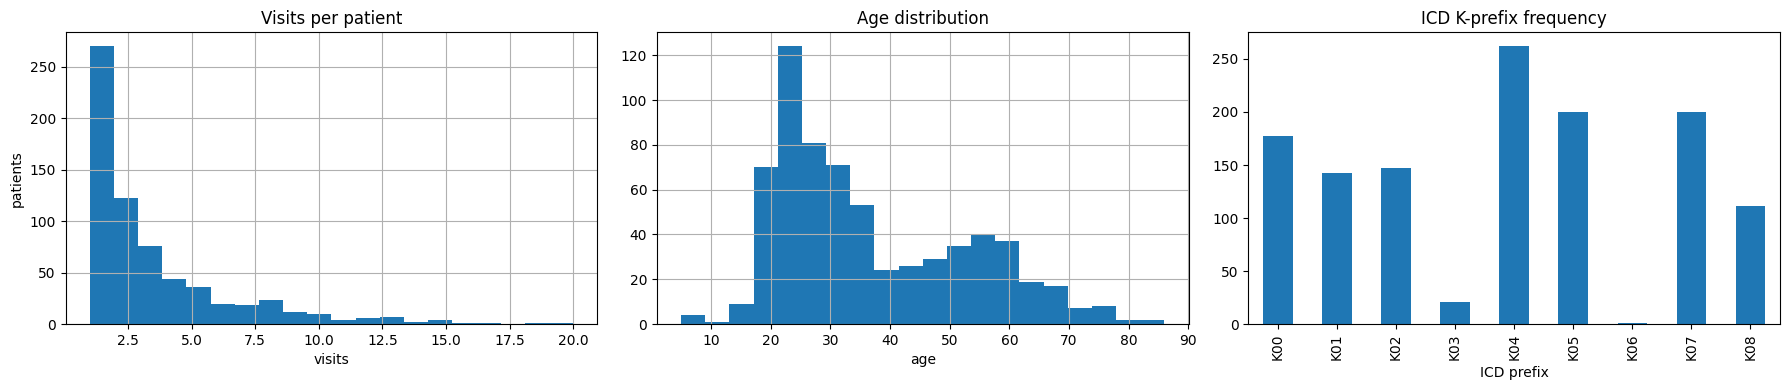

In [ ]:
def eda_mmdental_csv(records: pd.DataFrame, patient_records: pd.DataFrame) -> dict:
    outputs = {}

    print("=" * 60)
    print("MMDental CSV EDA")
    print("=" * 60)

    print(f"Rows:             {len(records):,}")
    print(f"Patients:         {records['patient_id'].nunique():,}")
    print(f"Patient rows:     {len(patient_records):,}")

    print("\nVisits per patient:")
    print(patient_records['n_visits'].describe().round(2))

    print("\nVisit type distribution:")
    print(records['visit_type'].value_counts(dropna=False))

    print("\nSex distribution:")
    print(patient_records['sex'].value_counts(dropna=False))

    print("\nAge summary:")
    print(patient_records[['age_median', 'age_min', 'age_max', 'age_nunique']].describe().round(2))

    print("\nPatients with changing age across visits:")
    changing_age = patient_records[patient_records['age_nunique'] > 1]
    print(changing_age[['patient_id', 'age_min', 'age_max', 'age_nunique']].head(20))

    print("\nField non-null percentage:")
    field_sparsity = records.notna().mean().sort_values(ascending=False) * 100
    print(field_sparsity.round(1).to_string())

    outputs['field_sparsity'] = field_sparsity.to_frame('pct_non_null')

    icd_full_pattern = re.compile(
        r'\b(K\d{2}(?:\.\d+[A-Za-z]*)?)\b',
        flags=re.IGNORECASE,
    )

    icd_prefix_pattern = re.compile(
        r'\b(K\d{2})(?:\.\d+[A-Za-z]*)?\b',
        flags=re.IGNORECASE,
    )

    label_text = (
        records['Diagnosis'].fillna('')
        + ' '
        + records['Oral Check'].fillna('')
    )

    full_codes = []
    prefixes = []

    for text in label_text:
        full_codes.extend([code.upper() for code in icd_full_pattern.findall(text)])
        prefixes.extend([code.upper() for code in icd_prefix_pattern.findall(text)])

    full_freq = pd.Series(full_codes).value_counts()
    prefix_freq = pd.Series(prefixes).value_counts()

    print("\nICD prefix frequency:")
    print(prefix_freq.to_string())

    print("\nTop 20 full ICD code frequency:")
    print(full_freq.head(20).to_string())

    outputs['icd_prefix_frequency'] = prefix_freq.to_frame('count')
    outputs['icd_full_frequency'] = full_freq.to_frame('count')

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    patient_records['n_visits'].hist(ax=axes[0], bins=20)
    axes[0].set_title('Visits per patient')
    axes[0].set_xlabel('visits')
    axes[0].set_ylabel('patients')

    if patient_records['age_median'].notna().any():
        patient_records['age_median'].dropna().hist(ax=axes[1], bins=20)
    axes[1].set_title('Age distribution')
    axes[1].set_xlabel('age')

    if len(prefix_freq):
        prefix_freq.sort_index().plot.bar(ax=axes[2])
    axes[2].set_title('ICD K-prefix frequency')
    axes[2].set_xlabel('ICD prefix')

    plt.tight_layout()
    plt.show()

    return outputs


csv_eda = eda_mmdental_csv(records_clean, patient_records_clean)

In [ ]:
def eda_mmdental_intensity(cohort: pd.DataFrame, sample_n: int = 50, force: bool = False) -> pd.DataFrame:
    """Audit MMDental CBCT intensity ranges so you can decide if the fixed HU
    clip is appropriate. This is the missing counterpart to the TF2 intensity EDA."""
    cache_path = MMD_LOG_DIR / 'mmd_intensity_audit.csv'
    if cache_path.exists() and not force:
        cached = pd.read_csv(cache_path)
        print(f"Loaded cached MMD intensity scan: {len(cached)} rows")
    else:
        rows = []
        sample = cohort.sample(min(sample_n, len(cohort)), random_state=SEED)
        for _, row in tqdm.auto.tqdm(sample.iterrows(), total=len(sample), desc='MMD intensity'):
            try:
                arr = sitk.GetArrayFromImage(sitk.ReadImage(row['nifti_path']))
                rows.append({
                    'patient_id': row['patient_id'],
                    'min': float(arr.min()), 'max': float(arr.max()),
                    'mean': float(arr.mean()), 'std': float(arr.std()),
                    'p01': float(np.percentile(arr, 1)),
                    'p05': float(np.percentile(arr, 5)),
                    'p50': float(np.percentile(arr, 50)),
                    'p95': float(np.percentile(arr, 95)),
                    'p99': float(np.percentile(arr, 99)),
                })
                del arr; gc.collect()
            except Exception as e:
                log.warning(f"{row['patient_id']}: intensity read failed ({e})")
        cached = pd.DataFrame(rows)
        cached.to_csv(cache_path, index=False)

    print("\nMMDental raw intensity stats:")
    print(cached[['min','max','mean','std','p01','p05','p50','p95','p99']].describe().round(1))
    print("\nCompare to TF2 (you saw earlier: min=-1000, p99≈1830, mean≈-81, std≈620).")
    print("If MMDental p01/p99 are very different from TF2, the fixed HU clip is wrong "
          "and you should keep use_percentile_clip=True.")
    return cached

## 7. BINARY LABEL EXTRACTION

In [ ]:
# ============================================================================
# MMDental BINARY PERIODONTITIS LABEL EXTRACTION
# ----------------------------------------------------------------------------
# Evidence hierarchy (record-derived only; never image-derived):
#   1. ICD sub-codes  (authoritative; the senior-reviewed coded diagnosis wins)
#         positive periodontitis : K05.2 K05.3 K05.4 K05.5 K05.6
#         confident negative     : K05.0 K05.1 (gingivitis), K06.x (gingival)
#         other non-perio        : K00-K04, K07, K08
#   2. Explicit negation         (overrides positive evidence)
#   3. Free-text evidence across Diagnosis, Oral Check, Past history,
#      Treatment plan, Handle  -> rescues code-less positives at medium conf;
#      two independent text sources agreeing -> high conf.
# Age and Sex are attached as patient metadata for downstream features /
# stratification ONLY. They are deliberately NOT inputs to the label, because
# periodontitis prevalence is age-correlated and using age to derive the label
# would re-encode that prior into the target the biomarker must audit.
# ============================================================================

PERIO_POSITIVE_SUBCODES = ('K05.2', 'K05.3', 'K05.4', 'K05.5', 'K05.6')
GINGIVITIS_SUBCODES     = ('K05.0', 'K05.1')          # gingivitis: no bone loss
GINGIVAL_PREFIXES       = ('K06',)                    # other gingival disorders

NON_PERIO_ICD_PREFIXES = ('K00', 'K01', 'K02', 'K03', 'K04', 'K07', 'K08')

ICD_FULL_PATTERN = re.compile(
    r'\b(K\d{2})(?:\.([0-9A-Za-z]+))?\b',
    flags=re.IGNORECASE,
)

MARGINAL_PERIO_RE = re.compile(
    r'(?<!apical )(?<!periapical )\bperiodontitis\b',
    flags=re.IGNORECASE,
)

# Explicit periodontitis terms (gingivitis/gingival-recession REMOVED).
PERIO_PHRASES = (
    'chronic periodontitis',
    'aggressive periodontitis',
    'localized aggressive periodontitis',
    'generalized aggressive periodontitis',
    'periodontal disease',
    'periodontal diseases',
    'periodontal abscess',
)

# Radiographic / clinical periodontitis SIGNS (Oral Check). Specific phrasing
# only; bare 'loose', 'tartar', 'calculus', 'bleeding' are too weak / shared
# with gingivitis and prophylaxis, so they are excluded.
PERIO_SIGN_PHRASES = (
    'periodontal pocket',
    'pocket depth',
    'attachment loss',
    'furcation',
    'alveolar bone loss',
    'alveolar bone resorption',
    'bone resorption',
    'tooth mobility',
    'loose tooth',
    'loose teeth',
    'degree of mobility',
)

# Periodontal THERAPY (Treatment plan / Handle). Routine supragingival
# scaling and polishing are deliberately excluded (done prophylactically).
PERIO_THERAPY_PHRASES = (
    'subgingival scaling',
    'subgingival curettage',
    'root planing',
    'periodontal flap',
    'gingival flap',
    'periodontal surgery',
    'periodontal therapy',
    'periodontal treatment',
    'guided tissue regeneration',
    'gtr',
    'gingivectomy',
)

GINGIVITIS_PHRASES = (
    'gingivitis',
    'chronic gingivitis',
    'whole-mouth chronic gingivitis',
    'gingival inflammation',
)

APICAL_CONTEXT_PHRASES = (
    'apical periodontitis',
    'chronic apical periodontitis',
    'acute apical periodontitis',
    'periapical periodontitis',
    'periapical lesion',
    'periapical abscess',
    'periapical inflammation',
)

NO_PERIODONTITIS_PHRASES = (
    'no periodontitis',
    'without periodontitis',
    'no periodontal disease',
    'without periodontal disease',
    'no obvious periodontitis',
    'no obvious periodontal disease',
    'periodontitis was not found',
    'periodontal disease was not found',
)

NON_PERIO_KEYWORDS = (
    'pulpitis', 'periapical', 'root canal', 'caries', 'carious', 'cavity',
    'impacted', 'embedded tooth', 'embedded teeth', 'residual root',
    'residual crown', 'fracture', 'broken tooth', 'missing tooth',
    'missing teeth', 'malformed', 'malposition', 'tooth wear',
    'wedge-shaped defect', 'wedge shaped defect',
)

NON_PERIO_REVIEW_PHRASES = (
    'after implantation', 'after tooth extraction', 'dental examination',
    'routine examination', 'orthodontic review', 'follow-up examination',
    'follow up examination', 'review after',
)


def extract_icd_codes(text: str) -> tuple[list[str], list[str]]:
    if not text:
        return [], []

    codes = []
    for prefix, suffix in ICD_FULL_PATTERN.findall(text):
        prefix = prefix.upper()
        code = prefix if not suffix else f'{prefix}.{suffix.upper()}'
        if code not in codes:
            codes.append(code)

    prefixes = []
    for code in codes:
        prefix = code.split('.')[0].upper()
        if prefix not in prefixes:
            prefixes.append(prefix)

    return codes, prefixes


def classify_icd(codes: list[str]) -> dict:
    """Resolve ICD codes into periodontitis / gingival / other-non-perio flags."""
    has_perio_positive = any(code[:5] in PERIO_POSITIVE_SUBCODES for code in codes)
    has_gingival = any(
        code[:5] in GINGIVITIS_SUBCODES or code[:3] in GINGIVAL_PREFIXES
        for code in codes
    )
    has_other_non_perio = any(
        code.split('.')[0] in NON_PERIO_ICD_PREFIXES for code in codes
    )
    return {
        'has_perio_positive': has_perio_positive,
        'has_gingival': has_gingival,
        'has_other_non_perio': has_other_non_perio,
    }


def find_phrases(text_lower: str, phrases: tuple[str, ...]) -> list[str]:
    return [phrase for phrase in phrases if phrase in text_lower]


def _join_column(group: pd.DataFrame, column: str) -> str:
    return ' '.join(
        value for value in group[column].tolist() if isinstance(value, str)
    )


def build_patient_evidence_text(group: pd.DataFrame) -> dict:
    """Split record evidence by clinical role so each source is auditable."""
    diagnosis    = _join_column(group, 'Diagnosis')
    oral_check   = _join_column(group, 'Oral Check')
    past_history = _join_column(group, 'Past medical history')
    treatment    = _join_column(group, 'Treatment plan')
    handle       = _join_column(group, 'Handle')

    return {
        # ICD codes live in Diagnosis; oral check occasionally repeats them.
        'icd_text':     f'{diagnosis} {oral_check}'.strip(),
        # Explicit perio / gingivitis / negation / apical / non-perio terms.
        'dx_text':      f'{diagnosis} {oral_check} {past_history}'.strip(),
        # Clinical signs of attachment / bone loss.
        'sign_text':    oral_check.strip(),
        # Periodontal procedures actually performed or planned.
        'therapy_text': f'{treatment} {handle}'.strip(),
        # Full clinical text for review-type phrases.
        'full_text':    f'{diagnosis} {oral_check} {past_history} '
                        f'{treatment} {handle}'.strip(),
    }


def _patient_metadata(group: pd.DataFrame) -> dict:
    """Age / Sex are metadata only and never influence the label."""
    age_values = pd.to_numeric(group['Age'], errors='coerce').dropna()
    sex_values = group['Sex'].dropna()
    return {
        'age_median': float(age_values.median()) if len(age_values) else np.nan,
        'sex': sex_values.mode().iloc[0] if len(sex_values) else None,
    }


def make_no_records_label(cfg: MMDConfig = CFG) -> dict:
    return {
        'binary_label': 0,
        'binary_class_name': cfg.binary_class_names[0],
        'label_source': 'no_records',
        'label_confidence': 'low',
        'sample_weight': cfg.default_non_periodontitis_weight,
        'age_median': np.nan,
        'sex': None,
        'icd_codes': '', 'icd_prefixes': '',
        'matched_perio_phrases': '', 'matched_perio_sign_phrases': '',
        'matched_perio_therapy_phrases': '', 'matched_gingivitis_phrases': '',
        'matched_non_perio_keywords': '', 'matched_apical_context_phrases': '',
        'matched_no_periodontitis_phrases': '', 'matched_non_perio_review_phrases': '',
    }


def extract_binary_label(group: pd.DataFrame, cfg: MMDConfig = CFG) -> dict:
    ev = build_patient_evidence_text(group)
    meta = _patient_metadata(group)

    icd_codes, icd_prefixes = extract_icd_codes(ev['icd_text'])
    icd = classify_icd(icd_codes)

    matched_perio = find_phrases(ev['dx_text'].lower(), PERIO_PHRASES)
    if MARGINAL_PERIO_RE.search(ev['dx_text']) and 'periodontitis' not in matched_perio:
      matched_perio = matched_perio + ['periodontitis']
    matched_sign     = find_phrases(ev['sign_text'].lower(),    PERIO_SIGN_PHRASES)
    matched_therapy  = find_phrases(ev['therapy_text'].lower(), PERIO_THERAPY_PHRASES)
    matched_gingiv   = find_phrases(ev['dx_text'].lower(),      GINGIVITIS_PHRASES)
    matched_apical   = find_phrases(ev['dx_text'].lower(),      APICAL_CONTEXT_PHRASES)
    matched_no_perio = find_phrases(ev['dx_text'].lower(),      NO_PERIODONTITIS_PHRASES)
    matched_non_perio = find_phrases(ev['dx_text'].lower(),     NON_PERIO_KEYWORDS)
    matched_review   = find_phrases(ev['full_text'].lower(),    NON_PERIO_REVIEW_PHRASES)

    base = {
        **meta,
        'icd_codes': ';'.join(icd_codes),
        'icd_prefixes': ';'.join(icd_prefixes),
        'matched_perio_phrases': ';'.join(matched_perio),
        'matched_perio_sign_phrases': ';'.join(matched_sign),
        'matched_perio_therapy_phrases': ';'.join(matched_therapy),
        'matched_gingivitis_phrases': ';'.join(matched_gingiv),
        'matched_non_perio_keywords': ';'.join(matched_non_perio),
        'matched_apical_context_phrases': ';'.join(matched_apical),
        'matched_no_periodontitis_phrases': ';'.join(matched_no_perio),
        'matched_non_perio_review_phrases': ';'.join(matched_review),
    }

    def result(label, source, confidence, weight):
        return {
            **base,
            'binary_label': label,
            'binary_class_name': cfg.binary_class_names[label],
            'label_source': source,
            'label_confidence': confidence,
            'sample_weight': weight,
        }

    # 1. Positive ICD contradicted by an explicit negation -> drop to negative.
    if icd['has_perio_positive'] and matched_no_perio:
        return result(0, 'icd_perio_contradicted_by_text', 'low',
                      cfg.default_non_periodontitis_weight)

    # 2. Authoritative coded periodontitis.
    if icd['has_perio_positive']:
        return result(1, 'icd_perio_positive', 'high', cfg.high_confidence_weight)

    # 3. Explicit negation with no positive code.
    if matched_no_perio:
        return result(0, 'explicit_no_periodontitis', 'medium',
                      cfg.medium_confidence_weight)

    # 4. Coded gingivitis / gingival disorder -> confident bone-loss-free negative.
    #    The coded diagnosis is authoritative, so this wins over text therapy/sign.
    if icd['has_gingival']:
        return result(0, 'icd_gingivitis_or_gingival', 'high',
                      cfg.high_confidence_weight)

    # 5. Two independent text sources agree on periodontitis -> high confidence.
    text_positive_sources = sum(
        bool(x) for x in (matched_perio, matched_sign, matched_therapy)
    )
    if text_positive_sources >= 2:
        return result(1, 'text_corroborated_perio', 'high',
                      cfg.high_confidence_weight)

    # 6-8. Single text source -> medium confidence positive (rescues code-less).
    if matched_perio:
        return result(1, 'keyword_perio_phrase', 'medium', cfg.medium_confidence_weight)
    if matched_therapy:
        return result(1, 'keyword_perio_therapy', 'medium', cfg.medium_confidence_weight)
    if matched_sign:
        return result(1, 'keyword_perio_sign', 'medium', cfg.medium_confidence_weight)

    # 9. Text gingivitis with no perio evidence -> negative.
    if matched_gingiv:
        return result(0, 'keyword_gingivitis', 'medium', cfg.medium_confidence_weight)

    # 10. Other coded non-perio condition only.
    if icd['has_other_non_perio']:
        return result(0, 'icd_other_only', 'high', cfg.high_confidence_weight)

    # 11-13. Weak negative text evidence.
    if matched_review:
        return result(0, 'keyword_review', 'medium', cfg.medium_confidence_weight)
    if matched_apical:
        return result(0, 'keyword_apical_non_perio', 'medium', cfg.medium_confidence_weight)
    if matched_non_perio:
        return result(0, 'keyword_non_perio', 'medium', cfg.medium_confidence_weight)

    # 14. No usable signal -> all-covered default negative, low weight.
    return result(0, 'no_signal', 'low', cfg.default_non_periodontitis_weight)


def test_label_extractor() -> None:
    def run_one(diagnosis=None, oral_check=None, treatment=None,
                handle=None, past=None) -> dict:
        return extract_binary_label(pd.DataFrame({
            'Diagnosis': [diagnosis], 'Oral Check': [oral_check],
            'Past medical history': [past], 'Treatment plan': [treatment],
            'Handle': [handle], 'Sex': ['female'], 'Age': [55.0],
        }))

    # (kwargs, expected_label, expected_source)
    cases = [
        (dict(diagnosis='K05.600 chronic periodontitis'), 1, 'icd_perio_positive'),
        (dict(diagnosis='k05.300 chronic periodontitis'), 1, 'icd_perio_positive'),
        (dict(diagnosis='K05.100 whole-mouth chronic gingivitis'), 0, 'icd_gingivitis_or_gingival'),
        (dict(diagnosis='K05.104 gingivitis'), 0, 'icd_gingivitis_or_gingival'),
        (dict(diagnosis='K06.901 gingival recession'), 0, 'icd_gingivitis_or_gingival'),
        (dict(diagnosis='K05.600 no periodontal disease'), 0, 'icd_perio_contradicted_by_text'),
        (dict(diagnosis='K04.002 chronic apical periodontitis'), 0, 'icd_other_only'),
        (dict(diagnosis='K05.300 chronic periodontitis; K04.500; K02.900 caries'), 1, 'icd_perio_positive'),
        (dict(diagnosis='chronic periodontitis'), 1, 'keyword_perio_phrase'),
        (dict(oral_check='periodontal pocket 5mm, tooth mobility'), 1, 'keyword_perio_sign'),
        (dict(handle='subgingival scaling and root planing'), 1, 'keyword_perio_therapy'),
        (dict(oral_check='periodontal pocket 6mm', handle='root planing'), 1, 'text_corroborated_perio'),
        (dict(diagnosis='whole-mouth chronic gingivitis'), 0, 'keyword_gingivitis'),
        (dict(diagnosis='apical periodontitis'), 0, 'keyword_apical_non_perio'),
        (dict(diagnosis='no periodontal disease'), 0, 'explicit_no_periodontitis'),
        (dict(diagnosis='caries on tooth *14'), 0, 'keyword_non_perio'),
        (dict(diagnosis='Nothing special'), 0, 'no_signal'),
        (dict(), 0, 'no_signal'),
    ]

    for kwargs, expected_label, expected_source in cases:
        r = run_one(**kwargs)
        assert r['binary_label'] == expected_label, (kwargs, r['binary_label'], expected_label)
        assert r['label_source'] == expected_source, (kwargs, r['label_source'], expected_source)

    codes, prefixes = extract_icd_codes('K05.600 chronic periodontitis; k04.002; K02.900 caries')
    assert codes == ['K05.600', 'K04.002', 'K02.900'], codes
    assert prefixes == ['K05', 'K04', 'K02'], prefixes

    print("✓ Label extractor regression tests passed.")


test_label_extractor()

✓ Label extractor regression tests passed.


## 8. BUILD PATIENT-LEVEL LABELS AND LABEL EDA

In [ ]:
def build_patient_label_table(records: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for patient_id, group in records.groupby('patient_id', sort=True):
        label_data = extract_binary_label(group)
        rows.append({'patient_id': patient_id, **label_data})

    label_table = pd.DataFrame(rows)
    label_table.to_csv(MMD_LOG_DIR / 'mmd_patient_binary_labels_all_records.csv', index=False)

    return label_table


patient_label_table = build_patient_label_table(records_clean)

print("=" * 60)
print("Patient-level binary label EDA")
print("=" * 60)

print(f"Patients labelled: {len(patient_label_table)}")

print("\nClass distribution:")
print(patient_label_table['binary_class_name'].value_counts(dropna=False))

print("\nLabel source distribution:")
print(patient_label_table['label_source'].value_counts(dropna=False))

print("\nConfidence distribution:")
print(patient_label_table['label_confidence'].value_counts(dropna=False))

print("\nSample weight distribution:")
print(patient_label_table['sample_weight'].value_counts(dropna=False).sort_index())

POSITIVE_LABEL_SOURCES = {
    'icd_perio_positive', 'text_corroborated_perio',
    'keyword_perio_phrase', 'keyword_perio_therapy', 'keyword_perio_sign',
}

bad_positive_source = patient_label_table[
    (patient_label_table['binary_label'] == 1)
    & (~patient_label_table['label_source'].isin(POSITIVE_LABEL_SOURCES))
]
assert len(bad_positive_source) == 0, (
    "PERIODONTITIS assigned via a non-positive label_source: "
    f"{bad_positive_source[['patient_id', 'label_source']].to_dict('records')[:10]}"
)
print("✓ Every PERIODONTITIS label comes from an approved positive source.")

bad_no_perio = patient_label_table[
    (patient_label_table['binary_label'] == 1)
    & (patient_label_table['matched_no_periodontitis_phrases'].fillna('') != '')
]
assert len(bad_no_perio) == 0, (
    "Explicit no-periodontitis evidence coexists with a PERIODONTITIS label."
)
print("✓ Explicit no-periodontitis phrases never yield PERIODONTITIS.")

apical_rows = patient_label_table[
    patient_label_table['label_source'] == 'keyword_apical_non_perio'
]
assert (apical_rows['binary_label'] == 0).all(), (
    "Apical/periapical source produced a positive label."
)
print("✓ Apical/periapical evidence is never positive.")

display(patient_label_table.head())

Patient-level binary label EDA
Patients labelled: 660

Class distribution:
binary_class_name
NON_PERIODONTITIS    508
PERIODONTITIS        152
Name: count, dtype: int64

Label source distribution:
label_source
icd_other_only                343
icd_perio_positive             92
icd_gingivitis_or_gingival     63
keyword_non_perio              53
keyword_perio_sign             37
no_signal                      31
text_corroborated_perio        10
keyword_perio_phrase           10
keyword_gingivitis              9
keyword_review                  7
keyword_perio_therapy           3
keyword_apical_non_perio        2
Name: count, dtype: int64

Confidence distribution:
label_confidence
high      508
medium    121
low        31
Name: count, dtype: int64

Sample weight distribution:
sample_weight
0.35     31
0.70    121
1.00    508
Name: count, dtype: int64
✓ Every PERIODONTITIS label comes from an approved positive source.
✓ Explicit no-periodontitis phrases never yield PERIODONTITIS.
✓ Apical/

,patient_id,age_median,sex,icd_codes,icd_prefixes,matched_perio_phrases,matched_perio_sign_phrases,matched_perio_therapy_phrases,matched_gingivitis_phrases,matched_non_perio_keywords,matched_apical_context_phrases,matched_no_periodontitis_phrases,matched_non_perio_review_phrases,binary_label,binary_class_name,label_source,label_confidence,sample_weight
0,1,20.0,female,K07.302,K07,,,,,malformed,,,,0,NON_PERIODONTITIS,icd_other_only,high,1.00
1,10,30.0,female,K05.100;K01.100,K05;K01,,,,gingivitis;chronic gingivitis;whole-mouth chro...,impacted,,,,0,NON_PERIODONTITIS,icd_gingivitis_or_gingival,high,1.00
2,100,25.0,female,K04.500,K04,,,,,,apical periodontitis;chronic apical periodontitis,,,0,NON_PERIODONTITIS,icd_other_only,high,1.00
3,101,42.0,male,,,,,,,,,,,0,NON_PERIODONTITIS,no_signal,low,0.35
4,102,59.0,male,K05.600;K00.001,K05;K00,periodontal disease,,,,,,,,1,PERIODONTITIS,icd_perio_positive,high,1.00


## 9. 3D MMDental DATASET PREPROCESSING

In [ ]:
def discover_nifti_files(raw_root: pathlib.Path) -> pd.DataFrame:
    nifti_paths = sorted(raw_root.glob('*/*.nii.gz'))

    rows = []

    for path in nifti_paths:
        file_id = path.name.replace('.nii.gz', '')
        patient_id = normalise_patient_id(file_id)

        rows.append({
            'patient_id': patient_id,
            'nifti_path': str(path),
            'nifti_file_id': file_id,
            'nifti_parent_dir': path.parent.name,
        })

    imaging = pd.DataFrame(rows)

    if len(imaging) == 0:
        raise RuntimeError(f"No .nii.gz files found under {raw_root}")

    duplicate_ids = imaging['patient_id'][imaging['patient_id'].duplicated()].tolist()

    if duplicate_ids:
        raise RuntimeError(f"Duplicate imaging patient IDs found: {duplicate_ids[:20]}")

    return imaging


def build_imaging_cohort(records: pd.DataFrame) -> pd.DataFrame:
    imaging = discover_nifti_files(MMDENTAL_RAW)

    records_by_patient = {
        str(patient_id): group
        for patient_id, group in records.groupby('patient_id')
    }

    rows = []

    for _, image_row in imaging.iterrows():
        patient_id = str(image_row['patient_id'])

        if patient_id in records_by_patient:
            label_data = extract_binary_label(records_by_patient[patient_id])
        else:
            label_data = make_no_records_label(CFG)

        rows.append({
            'patient_id': patient_id,
            'nifti_path': image_row['nifti_path'],
            'nifti_file_id': image_row['nifti_file_id'],
            'nifti_parent_dir': image_row['nifti_parent_dir'],
            **label_data,
        })

    cohort = pd.DataFrame(rows)
    # Cohort hygiene flags — used downstream for filtering or weighting
    age_lookup = (
        records.groupby('patient_id')['Age']
        .median()
        .to_dict()
    )
    cohort['age_median'] = cohort['patient_id'].map(age_lookup)
    cohort['pediatric'] = cohort['age_median'].fillna(99) < 18
    cohort['likely_edentulous'] = (
        cohort['matched_non_perio_keywords'].fillna('').str.contains('missing tooth|missing teeth', regex=True)
    )

    # Caveat: this is a "patient-ever" label, not "patient-at-CBCT-time" label
    cohort['label_timepoint_caveat'] = 'patient_ever_across_all_visits'

    print(f"\nCohort hygiene:")
    print(f"  Pediatric (<18): {cohort['pediatric'].sum()}")
    print(f"  Likely edentulous: {cohort['likely_edentulous'].sum()}")

    assert len(cohort) == len(imaging)
    assert cohort['binary_label'].notna().all()
    assert cohort['binary_label'].isin([0, 1]).all()
    assert cohort['binary_class_name'].notna().all()

    record_patient_ids = set(records['patient_id'].astype(str))
    imaging_patient_ids = set(cohort['patient_id'].astype(str))

    print("=" * 60)
    print("MMDental imaging cohort")
    print("=" * 60)

    print(f"Valid .nii.gz files:       {len(imaging)}")
    print(f"Imaging cohort size:       {len(cohort)}")
    print(f"With records:              {len(imaging_patient_ids & record_patient_ids)}")
    print(f"Imaging-only / no records: {len(imaging_patient_ids - record_patient_ids)}")
    print(f"Records without imaging:   {len(record_patient_ids - imaging_patient_ids)}")

    print("\nClass distribution:")
    print(cohort['binary_class_name'].value_counts(dropna=False))

    print("\nLabel source distribution:")
    print(cohort['label_source'].value_counts(dropna=False))

    print("\nConfidence distribution:")
    print(cohort['label_confidence'].value_counts(dropna=False))

    print("\nSample weight distribution:")
    print(cohort['sample_weight'].value_counts(dropna=False).sort_index())

    cohort.to_csv(MMD_LOG_DIR / 'mmd_imaging_cohort_with_labels.csv', index=False)

    return cohort


cohort = build_imaging_cohort(records_clean)

display(cohort.head())

mmd_intensity_audit = eda_mmdental_intensity(cohort, sample_n=50, force=True)


Cohort hygiene:
  Pediatric (<18): 10
  Likely edentulous: 81
MMDental imaging cohort
Valid .nii.gz files:       403
Imaging cohort size:       403
With records:              403
Imaging-only / no records: 0
Records without imaging:   257

Class distribution:
binary_class_name
NON_PERIODONTITIS    326
PERIODONTITIS         77
Name: count, dtype: int64

Label source distribution:
label_source
icd_other_only                235
icd_perio_positive             47
icd_gingivitis_or_gingival     33
keyword_non_perio              32
keyword_perio_sign             18
no_signal                      15
text_corroborated_perio         7
keyword_review                  5
keyword_gingivitis              5
keyword_perio_phrase            4
keyword_apical_non_perio        1
keyword_perio_therapy           1
Name: count, dtype: int64

Confidence distribution:
label_confidence
high      322
medium     66
low        15
Name: count, dtype: int64

Sample weight distribution:
sample_weight
0.35     15
0.70

,patient_id,nifti_path,nifti_file_id,nifti_parent_dir,age_median,sex,icd_codes,icd_prefixes,matched_perio_phrases,matched_perio_sign_phrases,...,matched_no_periodontitis_phrases,matched_non_perio_review_phrases,binary_label,binary_class_name,label_source,label_confidence,sample_weight,pediatric,likely_edentulous,label_timepoint_caveat
0,1,/content/drive/MyDrive/Teeth_Segmentation_Clas...,1,1,20.0,female,K07.302,K07,,,...,,,0,NON_PERIODONTITIS,icd_other_only,high,1.0,False,False,patient_ever_across_all_visits
1,10,/content/drive/MyDrive/Teeth_Segmentation_Clas...,10,10,30.0,female,K05.100;K01.100,K05;K01,,,...,,,0,NON_PERIODONTITIS,icd_gingivitis_or_gingival,high,1.0,False,False,patient_ever_across_all_visits
2,100,/content/drive/MyDrive/Teeth_Segmentation_Clas...,100,100,25.0,female,K04.500,K04,,,...,,,0,NON_PERIODONTITIS,icd_other_only,high,1.0,False,False,patient_ever_across_all_visits
3,102,/content/drive/MyDrive/Teeth_Segmentation_Clas...,102,102,59.0,male,K05.600;K00.001,K05;K00,periodontal disease,,...,,,1,PERIODONTITIS,icd_perio_positive,high,1.0,False,False,patient_ever_across_all_visits
4,104,/content/drive/MyDrive/Teeth_Segmentation_Clas...,104,104,36.0,male,K05.600,K05,periodontal disease,,...,,,1,PERIODONTITIS,icd_perio_positive,high,1.0,False,False,patient_ever_across_all_visits


MMD intensity:   0%|          | 0/50 [00:00<?, ?it/s]


MMDental raw intensity stats:
          min     max   mean    std     p01     p05    p50    p95     p99
count    50.0    50.0   50.0   50.0    50.0    50.0   50.0   50.0    50.0
mean  -1000.0  5797.3 -386.1  604.4 -1000.0 -1000.0 -346.1  567.7  1316.4
std       0.0  1468.2   59.8   19.0     0.0     0.0  268.3   70.6    70.4
min   -1000.0  3525.0 -493.9  549.6 -1000.0 -1000.0 -943.0  385.0  1173.0
25%   -1000.0  4069.2 -422.4  595.8 -1000.0 -1000.0 -483.5  524.5  1285.8
50%   -1000.0  7000.0 -392.8  603.3 -1000.0 -1000.0 -225.5  561.5  1316.0
75%   -1000.0  7000.0 -366.2  616.2 -1000.0 -1000.0 -164.2  611.5  1356.5
max   -1000.0  7000.0 -208.7  646.7 -1000.0 -1000.0  -81.0  727.0  1517.0

Compare to TF2 (you saw earlier: min=-1000, p99≈1830, mean≈-81, std≈620).
If MMDental p01/p99 are very different from TF2, the fixed HU clip is wrong and you should keep use_percentile_clip=True.


MMD headers: 100%|██████████| 403/403 [24:04<00:00,  3.58s/it]



MMDental imaging header summary:
           W      H      D      sx      sy      sz  file_mb
count  403.0  403.0  403.0  403.00  403.00  403.00  403.000
mean   640.0  640.0  400.0    0.25    0.25    0.25  161.129
std      0.0    0.0    0.0    0.00    0.00    0.00    6.486
min    640.0  640.0  400.0    0.25    0.25    0.25  136.767
25%    640.0  640.0  400.0    0.25    0.25    0.25  156.947
50%    640.0  640.0  400.0    0.25    0.25    0.25  161.593
75%    640.0  640.0  400.0    0.25    0.25    0.25  165.310
max    640.0  640.0  400.0    0.25    0.25    0.25  180.483

Anisotropy ratio: mean=1.000, max=1.000


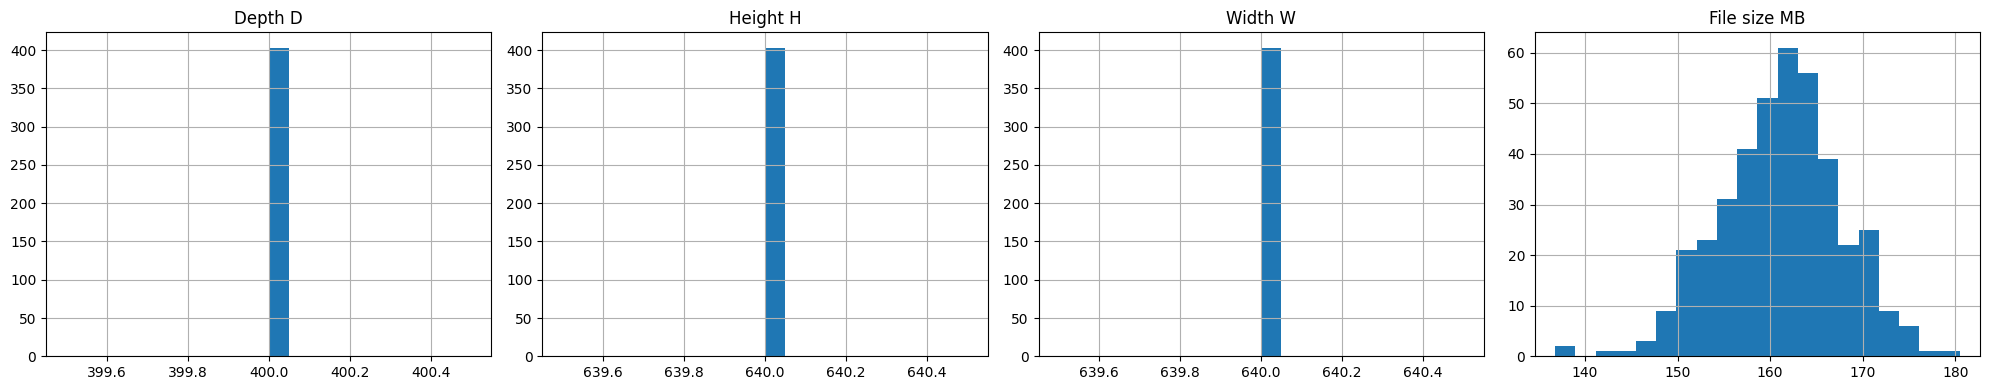

In [ ]:
def scan_imaging_headers(cohort: pd.DataFrame, force: bool = False) -> pd.DataFrame:
    cache_path = MMD_LOG_DIR / 'mmd_imaging_headers.csv'
    current_patient_ids = set(cohort['patient_id'].astype(str))

    if cache_path.exists() and not force:
        cached = pd.read_csv(cache_path)

        if set(cached['patient_id'].astype(str)) == current_patient_ids:
            print(f"Loaded cached header scan: {len(cached)} rows")
            return cached

        print("Header cache patient set differs from current cohort; recomputing.")

    rows = []
    reader = sitk.ImageFileReader()

    for _, row in tqdm.tqdm(cohort.iterrows(), total=len(cohort), desc='MMD headers'):
        patient_id = row['patient_id']
        nifti_path = pathlib.Path(row['nifti_path'])

        try:
            reader.SetFileName(str(nifti_path))
            reader.ReadImageInformation()

            size = reader.GetSize()
            spacing = reader.GetSpacing()

            rows.append({
                'patient_id': patient_id,
                'W': size[0],
                'H': size[1],
                'D': size[2],
                'sx': spacing[0],
                'sy': spacing[1],
                'sz': spacing[2],
                'voxels': size[0] * size[1] * size[2],
                'file_mb': nifti_path.stat().st_size / 1024 ** 2,
            })
        except Exception as error:
            log.warning(f"{patient_id}: header read failed ({error})")

    headers = pd.DataFrame(rows)
    headers.to_csv(cache_path, index=False)

    if len(headers) != len(cohort):
        missing = sorted(current_patient_ids - set(headers['patient_id'].astype(str)))
        raise RuntimeError(f"{len(missing)} imaging headers failed: {missing[:20]}")

    return headers


mmd_headers = scan_imaging_headers(cohort)

print("\nMMDental imaging header summary:")
print(mmd_headers[['W', 'H', 'D', 'sx', 'sy', 'sz', 'file_mb']].describe().round(3))

anisotropy = (
    mmd_headers[['sx', 'sy', 'sz']].max(axis=1)
    / mmd_headers[['sx', 'sy', 'sz']].min(axis=1)
)

print(f"\nAnisotropy ratio: mean={anisotropy.mean():.3f}, max={anisotropy.max():.3f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

mmd_headers['D'].hist(ax=axes[0], bins=20)
axes[0].set_title('Depth D')

mmd_headers['H'].hist(ax=axes[1], bins=20)
axes[1].set_title('Height H')

mmd_headers['W'].hist(ax=axes[2], bins=20)
axes[2].set_title('Width W')

mmd_headers['file_mb'].hist(ax=axes[3], bins=20)
axes[3].set_title('File size MB')

plt.tight_layout()
plt.show()

In [ ]:
def preprocess_mmd_volume_dual_space(
    patient_id: str,
    nifti_path: str,
    classifier_output_path: pathlib.Path,
    teacher_output_path: pathlib.Path,
    cfg: MMDConfig = CFG,
) -> tuple[bool, dict]:
    result = {
        'patient_id': patient_id,
        'nifti_path': str(nifti_path),
        'classifier_image_path': str(classifier_output_path),
        'teacher_image_path': str(teacher_output_path),
        'classifier_status': None,
        'teacher_status': None,
    }

    try:
        classifier_ok = False
        teacher_ok = False

        if cfg.skip_existing and classifier_output_path.exists():
            try:
                cached = np.load(classifier_output_path, mmap_mode='r')

                if (
                    tuple(cached.shape) == tuple(cfg.classifier_target_shape)
                    and cached.dtype == np.dtype(cfg.save_dtype_image)
                ):
                    classifier_ok = True
                    result['classifier_status'] = 'cached'
                    result['classifier_shape_d'] = int(cached.shape[0])
                    result['classifier_shape_h'] = int(cached.shape[1])
                    result['classifier_shape_w'] = int(cached.shape[2])
            except Exception as error:
                log.warning(f"{patient_id}: classifier cache unreadable ({error}); reprocessing")

        if cfg.skip_existing and teacher_output_path.exists():
            try:
                cached = np.load(teacher_output_path, mmap_mode='r')

                if cached.ndim == 3 and cached.dtype == np.dtype(cfg.save_dtype_image):
                    teacher_ok = True
                    result['teacher_status'] = 'cached'
                    result['teacher_shape_d'] = int(cached.shape[0])
                    result['teacher_shape_h'] = int(cached.shape[1])
                    result['teacher_shape_w'] = int(cached.shape[2])
            except Exception as error:
                log.warning(f"{patient_id}: teacher cache unreadable ({error}); reprocessing")

        if classifier_ok and teacher_ok:
            return True, result

        volume = load_file_volume(pathlib.Path(nifti_path))

        result['src_shape_d'] = int(volume['shape'][0])
        result['src_shape_h'] = int(volume['shape'][1])
        result['src_shape_w'] = int(volume['shape'][2])
        result['src_spacing_x'] = float(volume['spacing'][0])
        result['src_spacing_y'] = float(volume['spacing'][1])
        result['src_spacing_z'] = float(volume['spacing'][2])

        if not classifier_ok:
            classifier_resampled = resample_isotropic_to_shape(
                volume['array'],
                volume['spacing'],
                cfg.classifier_target_spacing,
                cfg.classifier_target_shape,
                is_label=False,
                src_origin=volume['origin'],
                src_direction=volume['direction'],
            )

            classifier_normalized = normalize_file_intensity(
                classifier_resampled,
                use_percentile_clip=cfg.use_percentile_clip,
                fixed_clip_range=cfg.fixed_clip_range,
                clip_percentiles=cfg.clip_percentiles,
            )

            np.save(
                classifier_output_path,
                classifier_normalized.astype(cfg.save_dtype_image),
            )

            result['classifier_status'] = 'processed'
            result['classifier_shape_d'] = int(classifier_normalized.shape[0])
            result['classifier_shape_h'] = int(classifier_normalized.shape[1])
            result['classifier_shape_w'] = int(classifier_normalized.shape[2])

            del classifier_resampled, classifier_normalized
            gc.collect()

        if not teacher_ok:
            teacher_resampled = resample_to_spacing(
                volume['array'],
                volume['spacing'],
                cfg.teacher_target_spacing,
                is_label=False,
                src_origin=volume['origin'],
                src_direction=volume['direction'],
            )

            teacher_normalized = normalize_file_intensity(
                teacher_resampled,
                use_percentile_clip=cfg.use_percentile_clip,
                fixed_clip_range=cfg.fixed_clip_range,
                clip_percentiles=cfg.clip_percentiles,
            )

            np.save(
                teacher_output_path,
                teacher_normalized.astype(cfg.save_dtype_image),
            )

            result['teacher_status'] = 'processed'
            result['teacher_shape_d'] = int(teacher_normalized.shape[0])
            result['teacher_shape_h'] = int(teacher_normalized.shape[1])
            result['teacher_shape_w'] = int(teacher_normalized.shape[2])

            del teacher_resampled, teacher_normalized
            gc.collect()

        del volume
        gc.collect()

        return True, result

    except Exception as error:
        result['error'] = str(error)
        return False, result


def preprocess_all_mmd_volumes_dual_space(
    cohort: pd.DataFrame,
    cfg: MMDConfig = CFG,
) -> pd.DataFrame:
    rows = []
    failed = []

    for _, row in tqdm.tqdm(
        cohort.iterrows(),
        total=len(cohort),
        desc='Preprocessing MMD dual-space',
    ):
        patient_id = str(row['patient_id'])

        classifier_output_path = MMD_IMG3D_DIR / f'{patient_id}.npy'
        teacher_output_path = MMD_TEACHER_IMG_DIR / f'{patient_id}.npy'

        ok, result = preprocess_mmd_volume_dual_space(
            patient_id=patient_id,
            nifti_path=row['nifti_path'],
            classifier_output_path=classifier_output_path,
            teacher_output_path=teacher_output_path,
            cfg=cfg,
        )

        if ok:
            rows.append(result)
        else:
            failed.append((patient_id, result.get('error', 'unknown_error')))
            log.error(f"{patient_id}: {result.get('error', 'unknown_error')}")

        gc.collect()

    if failed:
        error_path = MMD_LOG_DIR / 'mmd_dual_space_preprocessing_errors.txt'

        with open(error_path, 'w', encoding='utf-8') as file:
            for patient_id, reason in failed:
                file.write(f'{patient_id}\t{reason}\n')

        raise RuntimeError(
            f"{len(failed)} MMDental volumes failed preprocessing. "
            f"See {error_path}. First failures: {failed[:5]}"
        )

    volume_manifest = pd.DataFrame(rows)

    assert len(volume_manifest) == len(cohort), (
        f"Expected {len(cohort)} processed volumes, got {len(volume_manifest)}"
    )

    volume_manifest.to_csv(
        MMD_MANIFEST_DIR / 'manifest_volume_preprocessing.csv',
        index=False,
    )

    teacher_manifest = volume_manifest[
        [
            'patient_id',
            'nifti_path',
            'teacher_image_path',
            'teacher_shape_d',
            'teacher_shape_h',
            'teacher_shape_w',
            'teacher_status',
        ]
    ].copy()

    teacher_manifest['status'] = teacher_manifest['teacher_status']

    teacher_manifest.to_csv(
        MMD_MANIFEST_DIR / 'manifest_teacher_space.csv',
        index=False,
    )

    print("MMDental dual-space volume preprocessing complete.")

    print("\nClassifier status:")
    print(volume_manifest['classifier_status'].value_counts(dropna=False))

    print("\nTeacher status:")
    print(volume_manifest['teacher_status'].value_counts(dropna=False))

    print("\nClassifier-space shape summary:")
    print(
        volume_manifest[
            ['classifier_shape_d', 'classifier_shape_h', 'classifier_shape_w']
        ].describe().round(1)
    )

    print("\nTeacher-space shape summary:")
    print(
        volume_manifest[
            ['teacher_shape_d', 'teacher_shape_h', 'teacher_shape_w']
        ].describe().round(1)
    )

    return volume_manifest

volume_manifest = preprocess_all_mmd_volumes_dual_space(cohort, CFG)

display(volume_manifest.head())

Preprocessing MMD dual-space: 100%|██████████| 403/403 [1:17:35<00:00, 11.55s/it]


MMDental dual-space volume preprocessing complete.

Classifier status:
classifier_status
processed    403
Name: count, dtype: int64

Teacher status:
teacher_status
processed    403
Name: count, dtype: int64

Classifier-space shape summary:
       classifier_shape_d  classifier_shape_h  classifier_shape_w
count               403.0               403.0               403.0
mean                112.0               176.0               176.0
std                   0.0                 0.0                 0.0
min                 112.0               176.0               176.0
25%                 112.0               176.0               176.0
50%                 112.0               176.0               176.0
75%                 112.0               176.0               176.0
max                 112.0               176.0               176.0

Teacher-space shape summary:
       teacher_shape_d  teacher_shape_h  teacher_shape_w
count            403.0            403.0            403.0
mean             250.0

,patient_id,nifti_path,classifier_image_path,teacher_image_path,classifier_status,teacher_status,src_shape_d,src_shape_h,src_shape_w,src_spacing_x,src_spacing_y,src_spacing_z,classifier_shape_d,classifier_shape_h,classifier_shape_w,teacher_shape_d,teacher_shape_h,teacher_shape_w
0,1,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,processed,processed,400,640,640,0.25,0.25,0.25,112,176,176,250,400,400
1,10,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,processed,processed,400,640,640,0.25,0.25,0.25,112,176,176,250,400,400
2,100,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,processed,processed,400,640,640,0.25,0.25,0.25,112,176,176,250,400,400
3,102,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,processed,processed,400,640,640,0.25,0.25,0.25,112,176,176,250,400,400
4,104,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,processed,processed,400,640,640,0.25,0.25,0.25,112,176,176,250,400,400


In [ ]:
import typing

def make_subject_splits(
    dataframe: pd.DataFrame,
    val_frac: float,
    test_frac: float,
    seed: int = SEED,
) -> pd.DataFrame:
    """Stratified split on (binary_label × label_confidence) so that low/medium
    confidence cases are distributed proportionally across train/val/test."""
    if dataframe['binary_label'].nunique() != 2:
        raise ValueError("Need both classes for stratified splitting.")

    class_counts = dataframe['binary_label'].value_counts()
    if class_counts.min() < 3:
        raise ValueError(f"Too few samples in one class: {class_counts.to_dict()}")

    compound = (
        dataframe['binary_label'].astype(str)
        + '_'
        + dataframe['label_confidence'].astype(str)
    )
    stratum_counts = compound.value_counts()

    stratify_full: pd.Series

    if stratum_counts.min() >= 2:
        stratify_full = compound
        log.info(
            f"Stratifying on (binary_label × label_confidence): "
            f"{stratum_counts.to_dict()}"
        )
    else:
        stratify_full = dataframe['binary_label'].astype(int)
        log.warning(
            f"Smallest stratum has only {stratum_counts.min()} cases; "
            f"falling back to binary_label-only stratification"
        )

    train_pool_raw, test_df_raw = sklearn.model_selection.train_test_split(
        dataframe,
        test_size=test_frac,
        stratify=stratify_full,
        random_state=seed,
    )

    train_pool = typing.cast(pd.DataFrame, train_pool_raw)
    test_df = typing.cast(pd.DataFrame, test_df_raw)

    val_size = val_frac / (1.0 - test_frac)
    train_pool_strat = stratify_full.loc[train_pool.index]

    train_df_raw, val_df_raw = sklearn.model_selection.train_test_split(
        train_pool,
        test_size=val_size,
        stratify=train_pool_strat,
        random_state=seed,
    )

    train_df = typing.cast(pd.DataFrame, train_df_raw)
    val_df = typing.cast(pd.DataFrame, val_df_raw)

    return pd.concat(
        [
            train_df.assign(split='train'),
            val_df.assign(split='val'),
            test_df.assign(split='test'),
        ],
        ignore_index=True,
    )

processable = cohort.merge(
    volume_manifest[
        [
            'patient_id',
            'classifier_image_path',
            'teacher_image_path',
            'classifier_status',
            'teacher_status',
            'classifier_shape_d',
            'classifier_shape_h',
            'classifier_shape_w',
            'teacher_shape_d',
            'teacher_shape_h',
            'teacher_shape_w',
        ]
    ],
    on='patient_id',
    how='inner',
    validate='one_to_one',
)

assert len(processable) == len(cohort), (
    f"Silent cohort shrink detected: cohort={len(cohort)}, processable={len(processable)}"
)

splits = make_subject_splits(
    processable,
    val_frac=CFG.val_frac,
    test_frac=CFG.test_frac,
    seed=SEED,
)

manifest_columns = [
    'patient_id',
    'nifti_path',

    'classifier_image_path',
    'teacher_image_path',

    'binary_label',
    'binary_class_name',
    'label_source',
    'label_confidence',
    'sample_weight',

    'icd_codes',
    'icd_prefixes',
    'matched_perio_phrases',
    'matched_perio_sign_phrases',
    'matched_perio_therapy_phrases',
    'matched_gingivitis_phrases',
    'matched_non_perio_keywords',
    'matched_apical_context_phrases',
    'matched_no_periodontitis_phrases',
    'matched_non_perio_review_phrases',

    'split',

    'classifier_status',
    'teacher_status',

    'classifier_shape_d',
    'classifier_shape_h',
    'classifier_shape_w',

    'teacher_shape_d',
    'teacher_shape_h',
    'teacher_shape_w',

    'age_median',
    'pediatric',
    'likely_edentulous',
    'label_timepoint_caveat',
]

manifest = splits[manifest_columns].copy()
manifest['img_npy'] = manifest['classifier_image_path']
manifest['volume_path'] = manifest['classifier_image_path']
manifest.to_csv(MMD_MANIFEST_CSV, index=False)
manifest[['patient_id', 'split']].to_csv(MMD_SPLITS_CSV, index=False)

print(f"Saved manifest: {MMD_MANIFEST_CSV}")
print(f"Saved splits:   {MMD_SPLITS_CSV}")

print("\nSplit × class:")
print(manifest.groupby(['split', 'binary_class_name']).size().unstack(fill_value=0))

print("\nPositive rate per split:")
print(manifest.groupby('split')['binary_label'].mean().round(3))

print("\nLabel source per split:")
print(pd.crosstab(manifest['split'], manifest['label_source']))

print("\nSample weight per split:")
print(manifest.groupby(['split', 'sample_weight']).size().unstack(fill_value=0))

display(manifest.head())

Saved manifest: /content/drive/MyDrive/Teeth_Segmentation_Classification/Preprocessed_Dataset/MMDental/manifests/manifest.csv
Saved splits:   /content/drive/MyDrive/Teeth_Segmentation_Classification/Preprocessed_Dataset/MMDental/manifests/splits.csv

Split × class:
binary_class_name  NON_PERIODONTITIS  PERIODONTITIS
split                                              
test                              50             11
train                            227             54
val                               49             12

Positive rate per split:
split
test     0.180
train    0.192
val      0.197
Name: binary_label, dtype: float64

Label source per split:
label_source  icd_gingivitis_or_gingival  icd_other_only  icd_perio_positive  \
split                                                                          
test                                   5              36                   8   
train                                 23             163                  31   
val              

,patient_id,nifti_path,classifier_image_path,teacher_image_path,binary_label,binary_class_name,label_source,label_confidence,sample_weight,icd_codes,...,classifier_shape_w,teacher_shape_d,teacher_shape_h,teacher_shape_w,age_median,pediatric,likely_edentulous,label_timepoint_caveat,img_npy,volume_path
0,9,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,0,NON_PERIODONTITIS,icd_other_only,high,1.0,K01.100,...,176,250,400,400,34.0,False,False,patient_ever_across_all_visits,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
1,194,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,0,NON_PERIODONTITIS,keyword_non_perio,medium,0.7,,...,176,250,400,400,26.0,False,False,patient_ever_across_all_visits,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
2,294,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,1,PERIODONTITIS,text_corroborated_perio,high,1.0,K03.101;K00.001,...,176,250,400,400,64.0,False,True,patient_ever_across_all_visits,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
3,74,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,0,NON_PERIODONTITIS,icd_other_only,high,1.0,K00.002,...,176,250,400,400,65.0,False,False,patient_ever_across_all_visits,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...
4,215,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...,0,NON_PERIODONTITIS,icd_other_only,high,1.0,K01.100;K02.900,...,176,250,400,400,26.0,False,False,patient_ever_across_all_visits,/content/drive/MyDrive/Teeth_Segmentation_Clas...,/content/drive/MyDrive/Teeth_Segmentation_Clas...


In [ ]:
"""## ANATOMY DERIVATION UTILITIES (used by Stage-II at inference)"""
import scipy.ndimage

def derive_tooth_jaw_boundary(
    teeth_mask: np.ndarray,
    jaws_mask: np.ndarray,
    dilation: int = 2,
) -> np.ndarray:
    """Boundary where dilated teeth and dilated jaws overlap — the
    periodontal ligament / alveolar crest / furcation region."""
    teeth_b = teeth_mask.astype(bool, copy=False)
    jaws_b = jaws_mask.astype(bool, copy=False)

    teeth_dilated = np.asarray(
        scipy.ndimage.binary_dilation(teeth_b, iterations=dilation),
        dtype=bool,
    )
    jaws_dilated = np.asarray(
        scipy.ndimage.binary_dilation(jaws_b, iterations=dilation),
        dtype=bool,
    )

    return np.logical_and(teeth_dilated, jaws_dilated)


def derive_alveolar_crest(teeth_mask: np.ndarray, jaws_mask: np.ndarray, band_z: int = 5) -> np.ndarray:
    """Top of the jaws where teeth meet bone. Coarse: take the boundary
    region, then keep only the topmost band_z slices per (y, x) column."""
    boundary = derive_tooth_jaw_boundary(teeth_mask, jaws_mask, dilation=2)
    crest = np.zeros_like(boundary)
    # For each (y, x), find the topmost z that's in the boundary
    has = boundary.any(axis=0)
    z_top = np.where(has, boundary.argmax(axis=0), -1)
    for dz in range(band_z):
        ys, xs = np.where(z_top >= 0)
        zs = (z_top[ys, xs] + dz).clip(max=boundary.shape[0] - 1)
        crest[zs, ys, xs] = True
    return crest


def stage1_masks_for_pooling(seg_4class: np.ndarray) -> Dict[str, np.ndarray]:
    """Convenience: given a 4-class Stage-I output, return all masks
    that Stage-II will pool over."""
    teeth = (seg_4class == 1)
    jaws  = (seg_4class == 2)
    iac   = (seg_4class == 3)
    boundary = derive_tooth_jaw_boundary(teeth, jaws, dilation=2)
    crest    = derive_alveolar_crest(teeth, jaws, band_z=5)
    return {
        'teeth': teeth, 'jaws': jaws, 'iac': iac,
        'tooth_jaw_boundary': boundary,
        'alveolar_crest': crest,
    }


print("Anatomy derivation utilities loaded.")

Anatomy derivation utilities loaded.


## 10. OPEN-ENDED QA DATASET

In [ ]:
QA_QUESTION_TEMPLATES = {
    'periodontitis_status': (
        'Does this case show record-derived evidence of periodontitis?',
        'What is the weak binary periodontal label for this CBCT case?',
        'Is this case labelled as PERIODONTITIS or NON_PERIODONTITIS?',
    ),
    'record_diagnosis_summary': (
        'Summarize the record-derived dental diagnosis for this case.',
        'What diagnosis is documented in the clinical record?',
    ),
    'record_oral_findings_summary': (
        'Summarize the oral examination findings documented for this case.',
        'What oral check findings are documented in the record?',
    ),
}


def truncate_text(text: str | None, max_chars: int = CFG.text_max_chars) -> str | None:
    if not isinstance(text, str):
        return None

    text = text.strip()

    if not text:
        return None

    return text[:max_chars]


def label_explanation(row: pd.Series) -> str:
    label = int(row['binary_label'])
    class_name = row['binary_class_name']
    confidence = row['label_confidence']
    source = row['label_source']
    icd_codes = row.get('icd_codes', '')
    matched_perio = row.get('matched_perio_phrases', '')
    matched_apical = row.get('matched_apical_context_phrases', '')
    matched_no_perio = row.get('matched_no_periodontitis_phrases', '')

    if label == 1 and confidence == 'high':
        return (
            f"This case is labelled {class_name}. The label is high-confidence "
            f"because the clinical record contains periodontal ICD evidence: {icd_codes}."
        )

    if label == 1 and confidence == 'medium':
        return (
            f"This case is labelled {class_name}. The label is medium-confidence "
            f"because the record contains periodontal phrase evidence: {matched_perio}."
        )

    if source == 'explicit_no_periodontitis':
        return (
            f"This case is labelled {class_name}. The record contains an explicit "
            f"non-periodontitis statement: {matched_no_perio}."
        )

    if source == 'keyword_apical_non_perio':
        return (
            f"This case is labelled {class_name}. The record mentions apical or "
            f"periapical disease ({matched_apical}), which is treated as non-periodontitis "
            f"under this weak-labelling policy."
        )

    if confidence == 'high':
        return (
            f"This case is labelled {class_name}. The label is high-confidence because "
            f"the record contains non-periodontal ICD evidence: {icd_codes}."
        )

    if confidence == 'medium':
        return (
            f"This case is labelled {class_name}. The label is medium-confidence because "
            f"the record contains non-periodontal or review-type evidence."
        )

    return (
        f"This case is labelled {class_name} with low confidence. The available record "
        f"does not provide explicit evidence of periodontitis, so the all-covered "
        f"weak-labelling policy assigns NON_PERIODONTITIS with reduced sample weight."
    )

def _truncate_sentence_aware(text, max_chars: int):
    if not isinstance(text, str):
        return None
    text = text.strip()
    if not text:
        return None
    if len(text) <= max_chars:
        return text
    cut = text[:max_chars]
    for delim in ('. ', '; ', ', '):
        idx = cut.rfind(delim)
        if idx > max_chars * 0.5:
            return cut[:idx + 1].strip()
    idx = cut.rfind(' ')
    return cut[:idx].strip() if idx > 0 else cut.strip()

def build_qa_pairs(
    patient_records: pd.DataFrame,
    manifest: pd.DataFrame,
) -> pd.DataFrame:
    rng = np.random.default_rng(SEED)

    manifest_by_patient = manifest.set_index('patient_id', drop=False)
    patient_records_by_patient = patient_records.set_index('patient_id', drop=False)

    rows = []

    for patient_id, meta in manifest_by_patient.iterrows():
        # --- Periodontitis status: multiple paraphrased questions per patient ---
        question_options = QA_QUESTION_TEMPLATES['periodontitis_status']
        answer = label_explanation(meta)
        n_paraphrases = min(2, len(question_options))
        chosen = rng.choice(len(question_options), size=n_paraphrases, replace=False)
        for qi in chosen:
            rows.append({
                'patient_id': patient_id,
                'volume_path': meta['classifier_image_path'],
                'split': meta['split'],
                'question_category': 'periodontitis_status',
                'question': question_options[int(qi)],
                'answer': answer,
                'answer_source_column': 'derived_from_weak_label',
                'binary_label': int(meta['binary_label']),
                'binary_class_name': meta['binary_class_name'],
                'label_source': meta['label_source'],
                'label_confidence': meta['label_confidence'],
                'sample_weight': float(meta['sample_weight']),
            })

        if patient_id not in patient_records_by_patient.index:
            continue

        patient_row = typing.cast(pd.Series, patient_records_by_patient.loc[patient_id, :],)

        diagnosis_text = _truncate_sentence_aware(patient_row.get('Diagnosis_all'), 800)
        oral_check_text = _truncate_sentence_aware(patient_row.get('Oral Check_all'), 800)

        # --- Diagnosis summary ---
        if diagnosis_text and len(diagnosis_text) >= 20:
            question_options = QA_QUESTION_TEMPLATES['record_diagnosis_summary']
            question = question_options[int(rng.integers(0, len(question_options)))]
            rows.append({
                'patient_id': patient_id,
                'volume_path': meta['classifier_image_path'],
                'split': meta['split'],
                'question_category': 'record_diagnosis_summary',
                'question': question,
                'answer': diagnosis_text,
                'answer_source_column': 'Diagnosis_all',
                'binary_label': int(meta['binary_label']),
                'binary_class_name': meta['binary_class_name'],
                'label_source': meta['label_source'],
                'label_confidence': meta['label_confidence'],
                'sample_weight': float(meta['sample_weight']),
            })

        # --- Oral findings summary ---
        if oral_check_text and len(oral_check_text) >= 20:
            question_options = QA_QUESTION_TEMPLATES['record_oral_findings_summary']
            question = question_options[int(rng.integers(0, len(question_options)))]
            rows.append({
                'patient_id': patient_id,
                'volume_path': meta['classifier_image_path'],
                'split': meta['split'],
                'question_category': 'record_oral_findings_summary',
                'question': question,
                'answer': oral_check_text,
                'answer_source_column': 'Oral Check_all',
                'binary_label': int(meta['binary_label']),
                'binary_class_name': meta['binary_class_name'],
                'label_source': meta['label_source'],
                'label_confidence': meta['label_confidence'],
                'sample_weight': float(meta['sample_weight']),
            })

    return pd.DataFrame(rows)


qa_df = build_qa_pairs(patient_records_clean, manifest)

with open(MMD_QA_JSONL, 'w', encoding='utf-8') as file:
    for _, row in qa_df.iterrows():
        file.write(json.dumps(row.to_dict(), ensure_ascii=False) + '\n')

print(f"Saved QA JSONL: {MMD_QA_JSONL}")
print(f"QA rows: {len(qa_df)}")

print("\nQA category distribution:")
print(qa_df['question_category'].value_counts(dropna=False))

print("\nQA split distribution:")
print(qa_df['split'].value_counts(dropna=False))

display(qa_df.head())

Saved QA JSONL: /content/drive/MyDrive/Teeth_Segmentation_Classification/Preprocessed_Dataset/MMDental/qa/qa_pairs.jsonl
QA rows: 1562

QA category distribution:
question_category
periodontitis_status            806
record_oral_findings_summary    391
record_diagnosis_summary        365
Name: count, dtype: int64

QA split distribution:
split
train    1090
val       238
test      234
Name: count, dtype: int64


,patient_id,volume_path,split,question_category,question,answer,answer_source_column,binary_label,binary_class_name,label_source,label_confidence,sample_weight
0,9,/content/drive/MyDrive/Teeth_Segmentation_Clas...,train,periodontitis_status,Does this case show record-derived evidence of...,This case is labelled NON_PERIODONTITIS. The l...,derived_from_weak_label,0,NON_PERIODONTITIS,icd_other_only,high,1.0
1,9,/content/drive/MyDrive/Teeth_Segmentation_Clas...,train,periodontitis_status,Is this case labelled as PERIODONTITIS or NON_...,This case is labelled NON_PERIODONTITIS. The l...,derived_from_weak_label,0,NON_PERIODONTITIS,icd_other_only,high,1.0
2,9,/content/drive/MyDrive/Teeth_Segmentation_Clas...,train,record_diagnosis_summary,Summarize the record-derived dental diagnosis ...,*28 impacted teeth (K01.100),Diagnosis_all,0,NON_PERIODONTITIS,icd_other_only,high,1.0
3,9,/content/drive/MyDrive/Teeth_Segmentation_Clas...,train,record_oral_findings_summary,Summarize the oral examination findings docume...,"*28 Vertical impaction, large area of ​​tooth ...",Oral Check_all,0,NON_PERIODONTITIS,icd_other_only,high,1.0
4,194,/content/drive/MyDrive/Teeth_Segmentation_Clas...,train,periodontitis_status,What is the weak binary periodontal label for ...,This case is labelled NON_PERIODONTITIS. The l...,derived_from_weak_label,0,NON_PERIODONTITIS,keyword_non_perio,medium,0.7


In [ ]:
def run_final_sanity_checks(
    manifest: pd.DataFrame,
    qa_df: pd.DataFrame,
    cfg: MMDConfig = CFG,
) -> None:
    assert manifest['binary_label'].notna().all()
    assert manifest['binary_label'].isin([0, 1]).all()
    assert manifest['binary_class_name'].notna().all()

    print("✓ Every imaging patient has binary_label in {0, 1}")

    missing_classifier = []
    missing_teacher = []
    classifier_shape_errors = []
    classifier_dtype_errors = []
    teacher_shape_errors = []
    teacher_dtype_errors = []

    for _, row in tqdm.auto.tqdm(
        manifest.iterrows(),
        total=len(manifest),
        desc='Dual-space volume audit',
    ):
        classifier_path = pathlib.Path(row['classifier_image_path'])
        teacher_path = pathlib.Path(row['teacher_image_path'])

        if not classifier_path.exists():
            missing_classifier.append(row['patient_id'])
            continue

        if not teacher_path.exists():
            missing_teacher.append(row['patient_id'])
            continue

        classifier_array = np.load(classifier_path, mmap_mode='r')
        teacher_array = np.load(teacher_path, mmap_mode='r')

        if tuple(classifier_array.shape) != tuple(cfg.classifier_target_shape):
            classifier_shape_errors.append(
                (row['patient_id'], tuple(classifier_array.shape))
            )

        if classifier_array.dtype != np.dtype(cfg.save_dtype_image):
            classifier_dtype_errors.append(
                (row['patient_id'], str(classifier_array.dtype))
            )

        if teacher_array.ndim != 3:
            teacher_shape_errors.append(
                (row['patient_id'], tuple(teacher_array.shape))
            )

        if min(teacher_array.shape) < cfg.classifier_target_shape[0]:
            teacher_shape_errors.append(
                (row['patient_id'], tuple(teacher_array.shape))
            )

        if teacher_array.dtype != np.dtype(cfg.save_dtype_image):
            teacher_dtype_errors.append(
                (row['patient_id'], str(teacher_array.dtype))
            )

    assert not missing_classifier, f"Missing classifier volumes: {missing_classifier[:10]}"
    assert not missing_teacher, f"Missing teacher volumes: {missing_teacher[:10]}"
    assert not classifier_shape_errors, f"Classifier shape errors: {classifier_shape_errors[:10]}"
    assert not classifier_dtype_errors, f"Classifier dtype errors: {classifier_dtype_errors[:10]}"
    assert not teacher_shape_errors, f"Teacher-space shape errors: {teacher_shape_errors[:10]}"
    assert not teacher_dtype_errors, f"Teacher dtype errors: {teacher_dtype_errors[:10]}"

    print(
        f"✓ All classifier-space volumes exist with "
        f"shape={cfg.classifier_target_shape}, dtype={cfg.save_dtype_image}"
    )
    print("✓ All teacher-space volumes exist as valid 3D float32 arrays")

    sample_cases = manifest.sample(min(20, len(manifest)), random_state=SEED)

    intensity_rows = []

    for _, row in tqdm.auto.tqdm(
        sample_cases.iterrows(),
        total=len(sample_cases),
        desc='Intensity audit',
    ):
        classifier_array = np.load(row['classifier_image_path'])
        teacher_array = np.load(row['teacher_image_path'])

        classifier_tissue = classifier_array[
            classifier_array > np.percentile(classifier_array, 5)
        ]
        teacher_tissue = teacher_array[
            teacher_array > np.percentile(teacher_array, 5)
        ]

        if len(classifier_tissue) == 0:
            classifier_tissue = classifier_array.ravel()

        if len(teacher_tissue) == 0:
            teacher_tissue = teacher_array.ravel()

        intensity_rows.append({
            'patient_id': row['patient_id'],

            'classifier_mean': float(classifier_array.mean()),
            'classifier_std': float(classifier_array.std()),
            'classifier_min': float(classifier_array.min()),
            'classifier_max': float(classifier_array.max()),
            'classifier_tissue_mean': float(classifier_tissue.mean()),
            'classifier_tissue_std': float(classifier_tissue.std()),

            'teacher_mean': float(teacher_array.mean()),
            'teacher_std': float(teacher_array.std()),
            'teacher_min': float(teacher_array.min()),
            'teacher_max': float(teacher_array.max()),
            'teacher_tissue_mean': float(teacher_tissue.mean()),
            'teacher_tissue_std': float(teacher_tissue.std()),
        })

    intensity_df = pd.DataFrame(intensity_rows)
    intensity_df.to_csv(MMD_LOG_DIR / 'mmd_dual_space_intensity_audit.csv', index=False)

    print("\nIntensity audit sample:")
    print(intensity_df.round(3).head())

    intensity_numeric = intensity_df.drop(columns=['patient_id'])

    assert np.isfinite(intensity_numeric.to_numpy()).all()
    assert intensity_df['classifier_std'].between(0.5, 1.8).all()
    assert intensity_df['teacher_std'].between(0.5, 1.8).all()
    assert intensity_df['classifier_tissue_mean'].abs().max() < 0.5
    assert intensity_df['teacher_tissue_mean'].abs().max() < 0.5
    assert intensity_df['classifier_tissue_std'].between(0.5, 1.8).all()
    assert intensity_df['teacher_tissue_std'].between(0.5, 1.8).all()

    print("✓ Intensity sanity check passed on sampled classifier and teacher volumes")

    patient_split_counts = manifest.groupby('patient_id')['split'].nunique()
    leaked = patient_split_counts[patient_split_counts > 1]

    assert len(leaked) == 0, f"Patient leakage found: {leaked.head().to_dict()}"

    print("✓ No patient leakage across train/val/test splits")

    qa_split_check = qa_df.merge(
        manifest[['patient_id', 'split']].rename(columns={'split': 'manifest_split'}),
        on='patient_id',
        how='left',
    )

    split_mismatch = qa_split_check[
        qa_split_check['split'] != qa_split_check['manifest_split']
    ]

    assert len(split_mismatch) == 0, f"QA split mismatch rows: {len(split_mismatch)}"

    print(f"✓ All {len(qa_df)} QA rows match manifest split")

    for split_name, split_df in manifest.groupby('split'):
        positive_rate = split_df['binary_label'].mean()

        assert 0.01 < positive_rate < 0.99, (
            f"{split_name} split has degenerate class balance: {positive_rate:.3f}"
        )

    print("✓ All splits have non-degenerate class balance")

    # ---- Label invariants (keyed off label_source, robust to widened evidence) ----
    POSITIVE_LABEL_SOURCES = {
        'icd_perio_positive', 'text_corroborated_perio',
        'keyword_perio_phrase', 'keyword_perio_therapy', 'keyword_perio_sign',
    }

    bad_positive_source = manifest[
        (manifest['binary_label'] == 1)
        & (~manifest['label_source'].isin(POSITIVE_LABEL_SOURCES))
    ]
    assert len(bad_positive_source) == 0, (
        "PERIODONTITIS assigned via a non-positive label_source: "
        f"{bad_positive_source[['patient_id', 'label_source']].to_dict('records')[:10]}"
    )
    print("✓ Every PERIODONTITIS label comes from an approved positive source.")

    bad_no_perio = manifest[
        (manifest['binary_label'] == 1)
        & (manifest['matched_no_periodontitis_phrases'].fillna('') != '')
    ]
    assert len(bad_no_perio) == 0, (
        "Explicit no-periodontitis evidence coexists with a PERIODONTITIS label."
    )
    print("✓ Explicit no-periodontitis phrases did not trigger PERIODONTITIS")

    apical_rows = manifest[manifest['label_source'] == 'keyword_apical_non_perio']
    assert (apical_rows['binary_label'] == 0).all(), (
        "Apical/periapical source produced a positive label."
    )
    print("✓ Apical/periapical-only evidence did not trigger PERIODONTITIS")

    # ---- Visualization sweep: 10 random middle slices for eyeball QA ----
    vis_dir = MMD_LOG_DIR / 'visual_qa'
    vis_dir.mkdir(exist_ok=True)
    sample = manifest.sample(min(10, len(manifest)), random_state=SEED + 1)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, (_, row) in zip(axes.flat, sample.iterrows()):
        arr = np.load(row['classifier_image_path'])
        z = arr.shape[0] // 2
        ax.imshow(arr[z], cmap='gray')
        ax.set_title(f"{row['patient_id']} | {row['binary_class_name'][:7]}\n"
                     f"src=({row.get('src_shape_d','?')},{row.get('src_shape_h','?')},{row.get('src_shape_w','?')})",
                     fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(vis_dir / 'mmd_middle_slices_sample.png', dpi=110)
    plt.close()
    print(f"✓ Visual QA sweep saved to {vis_dir / 'mmd_middle_slices_sample.png'}")

    print("\n" + "=" * 60)
    print("MMDental preprocessing complete")
    print("=" * 60)
    print(f"Manifest:                 {MMD_MANIFEST_CSV}")
    print(f"Splits:                   {MMD_SPLITS_CSV}")
    print(f"Classifier-space volumes: {MMD_IMG3D_DIR}")
    print(f"Teacher-space volumes:    {MMD_TEACHER_IMG_DIR}")
    print(f"QA JSONL:                 {MMD_QA_JSONL}")
    print(f"Logs:                     {MMD_LOG_DIR}")

    print("\nFinal cohort:")
    print(manifest['binary_class_name'].value_counts(dropna=False))

    print("\nFinal label source distribution:")
    print(manifest['label_source'].value_counts(dropna=False))

    print("\nFinal sample weight distribution:")
    print(manifest['sample_weight'].value_counts(dropna=False).sort_index())


run_final_sanity_checks(manifest, qa_df, CFG)

✓ Every imaging patient has binary_label in {0, 1}


Dual-space volume audit:   0%|          | 0/403 [00:00<?, ?it/s]

✓ All classifier-space volumes exist with shape=(112, 176, 176), dtype=float32
✓ All teacher-space volumes exist as valid 3D float32 arrays


Intensity audit:   0%|          | 0/20 [00:00<?, ?it/s]


Intensity audit sample:
  patient_id  classifier_mean  classifier_std  classifier_min  classifier_max  \
0        466           -1.019           1.174          -1.913           3.324   
1        425           -1.032           1.216          -1.997           3.173   
2        252           -0.956           1.135          -1.809           3.098   
3        109           -1.009           1.167          -1.896           3.024   
4        519           -1.077           1.242          -2.066           3.067   

   classifier_tissue_mean  classifier_tissue_std  teacher_mean  teacher_std  \
0                    -0.0                    1.0        -0.488        1.112   
1                    -0.0                    1.0        -0.492        1.142   
2                    -0.0                    1.0        -0.456        1.093   
3                     0.0                    1.0        -0.480        1.108   
4                    -0.0                    1.0        -0.502        1.149   

   teacher_mi